<a href="https://colab.research.google.com/github/selim679/satellite-land-classification/blob/main/Copie_de_satellite_imagery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
gallo33henrique_sentinel_2_satellite_imagery_path = kagglehub.dataset_download('gallo33henrique/sentinel-2-satellite-imagery')

print('Data source import complete.')


# 🛰️ Land Use Classification Using Deep CNNs and Transfer Learning
## EuroSAT / Sentinel-2 Satellite Imagery Dataset

---

> **Author:** Your Name  
> **Date:** 2025  
> **Framework:** TensorFlow / Keras  
> **Hardware:** Kaggle GPU (T4 / P100)  

---

## 1. 📌 Introduction

### Problem Statement

Satellite image classification is one of the most impactful applications of computer vision. With the rise of high-resolution earth observation satellites such as **Sentinel-2** (operated by the European Space Agency), we now have access to terabytes of multispectral imagery covering the entire globe at regular intervals.

**Land use and land cover (LULC)** classification is the process of assigning semantic categories (e.g., Forest, River, Industrial Area) to satellite image patches. This task is critical for:

- 🌍 **Environmental monitoring** — deforestation, desertification tracking
- 🏙️ **Urban planning** — identifying growth patterns
- 🌾 **Agriculture** — crop type mapping and yield estimation
- 🚨 **Disaster management** — flood/fire damage assessment
- 🗺️ **Geospatial intelligence** — automated map generation

### The EuroSAT Dataset

The **EuroSAT** dataset is a benchmark dataset for land use classification based on Sentinel-2 satellite imagery. It contains:

- **27,000** labeled RGB images (64×64 pixels)
- **10 distinct classes** covering European land use types
- Images collected over 34 cities across Europe
- Publicly available and widely used in academic research

**Classes include:**
| Class | Description |
|---|---|
| AnnualCrop | Annual agricultural crops |
| Forest | Dense forest areas |
| HerbaceousVegetation | Grasslands and meadows |
| Highway | Major road infrastructure |
| Industrial | Industrial zones |
| Pasture | Grazing land |
| PermanentCrop | Orchards, vineyards |
| Residential | Urban residential zones |
| River | Rivers and waterways |
| SeaLake | Seas, lakes, and water bodies |

### Project Objectives

In this notebook, we will:

1. Build a **custom CNN baseline** for satellite image classification
2. Apply **Transfer Learning** using state-of-the-art pretrained models (ResNet50, EfficientNetB0)
3. Implement **fine-tuning** strategies for maximum performance
4. Apply **Grad-CAM** for model interpretability and explainability
5. Perform thorough **model comparison** and error analysis

### Why Transfer Learning?

Training deep CNNs from scratch requires millions of labeled images and days of compute. **Transfer Learning** solves this by leveraging models pretrained on ImageNet (1.4M images, 1000 classes). The low-level features learned (edges, textures, shapes) generalize well to satellite imagery, dramatically reducing training time and data requirements while improving accuracy.

---

## 2. 📦 Imports and Environment Setup

In [ ]:
import os
import random
import time
import warnings
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, mixed_precision
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

import cv2

warnings.filterwarnings('ignore')


SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

mixed_precision.set_global_policy('mixed_float16')
print(f"Mixed precision policy: {mixed_precision.global_policy()}")


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f" GPU detected: {[g.name for g in gpus]}")
else:
    print("No GPU detected — running on CPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

Mixed precision policy: <DTypePolicy "mixed_float16">
 GPU detected: ['/physical_device:GPU:0', '/physical_device:GPU:1']
TensorFlow version: 2.19.0
Keras version: 3.10.0


## 3. 📂 Data Loading

In [ ]:

IMG_SIZE    = 64          # EuroSAT native resolution
BATCH_SIZE  = 64
EPOCHS_BASE = 20
EPOCHS_TL   = 30          # Transfer learning epochs (freeze)
EPOCHS_FT   = 15          # Fine-tuning epochs (unfreeze)

DATASET_ROOT = None
SEARCH_PATHS = [
    '/kaggle/input/sentinel-2-satellite-imagery',
    '/kaggle/input/eurosat',
    '/kaggle/input/eurosat-dataset',
]

for path in SEARCH_PATHS:
    p = Path(path)
    if p.exists():
        DATASET_ROOT = p
        break

if DATASET_ROOT is None:
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        for d in kaggle_input.iterdir():
            subdirs = [x for x in d.rglob('*') if x.is_dir()]
            if any(len(list(sd.glob('*.jpg')) + list(sd.glob('*.png'))) > 10
                   for sd in subdirs):
                DATASET_ROOT = d
                break

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Dataset not found. Ensure the Kaggle dataset is attached under "
        "/kaggle/input/sentinel-2-satellite-imagery"
    )

print(f"✅ Dataset root: {DATASET_ROOT}")

def find_class_dir(root: Path) -> Path:
    """Walk the directory tree to find the parent of class folders."""
    for d in [root] + list(root.rglob('*')):
        if d.is_dir():
            children = [c for c in d.iterdir() if c.is_dir()]
            if len(children) >= 5:  # at least 5 class subdirectories
                img_counts = [len(list(c.glob('*.jpg')) + list(c.glob('*.png')))
                              for c in children]
                if sum(img_counts) > 500:
                    return d
    return root

DATA_DIR = find_class_dir(DATASET_ROOT)
print(f"✅ Image directory: {DATA_DIR}")

CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

class_counts = {}
all_images   = []
all_labels   = []

for idx, cls in enumerate(CLASS_NAMES):
    cls_dir = DATA_DIR / cls
    imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
    class_counts[cls] = len(imgs)
    all_images.extend(imgs)
    all_labels.extend([idx] * len(imgs))

total_images = len(all_images)

print(f"\n{'='*50}")
print(f"  DATASET STATISTICS")
print(f"{'='*50}")
print(f"  Total images  : {total_images:,}")
print(f"  Num classes   : {NUM_CLASSES}")
print(f"  Classes       : {CLASS_NAMES}")
print(f"{'='*50}")
print("\nImages per class:")
for cls, cnt in class_counts.items():
    bar = '█' * (cnt // 100)
    print(f"  {cls:<25} {cnt:>5}  {bar}")

✅ Dataset root: /kaggle/input/datasets
✅ Image directory: /kaggle/input/datasets/gallo33henrique/sentinel-2-satellite-imagery/EuroSAT/2750

  DATASET STATISTICS
  Total images  : 27,000
  Num classes   : 10
  Classes       : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Images per class:
  AnnualCrop                 3000  ██████████████████████████████
  Forest                     3000  ██████████████████████████████
  HerbaceousVegetation       3000  ██████████████████████████████
  Highway                    2500  █████████████████████████
  Industrial                 2500  █████████████████████████
  Pasture                    2000  ████████████████████
  PermanentCrop              2500  █████████████████████████
  Residential                3000  ██████████████████████████████
  River                      2500  █████████████████████████
  SeaLake                    3000  ████████████████████

In [ ]:
# ── Train / Validation / Test Split ───────────────────────────
# Strategy: 70% train | 15% validation | 15% test

all_images = np.array(all_images)
all_labels = np.array(all_labels)

# First split: 85% train+val | 15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_images, all_labels,
    test_size=0.15, stratify=all_labels, random_state=SEED
)

# Second split: 70% train | 15% val (from the 85%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.176, stratify=y_trainval, random_state=SEED
)

print(f"\n{'='*50}")
print(f"  DATASET SPLITS")
print(f"{'='*50}")
print(f"  Train       : {len(X_train):>6,} images  ({100*len(X_train)/total_images:.1f}%)")
print(f"  Validation  : {len(X_val):>6,} images  ({100*len(X_val)/total_images:.1f}%)")
print(f"  Test        : {len(X_test):>6,} images  ({100*len(X_test)/total_images:.1f}%)")
print(f"{'='*50}")


  DATASET SPLITS
  Train       : 18,910 images  (70.0%)
  Validation  :  4,040 images  (15.0%)
  Test        :  4,050 images  (15.0%)


## 4. 📊 Data Visualization

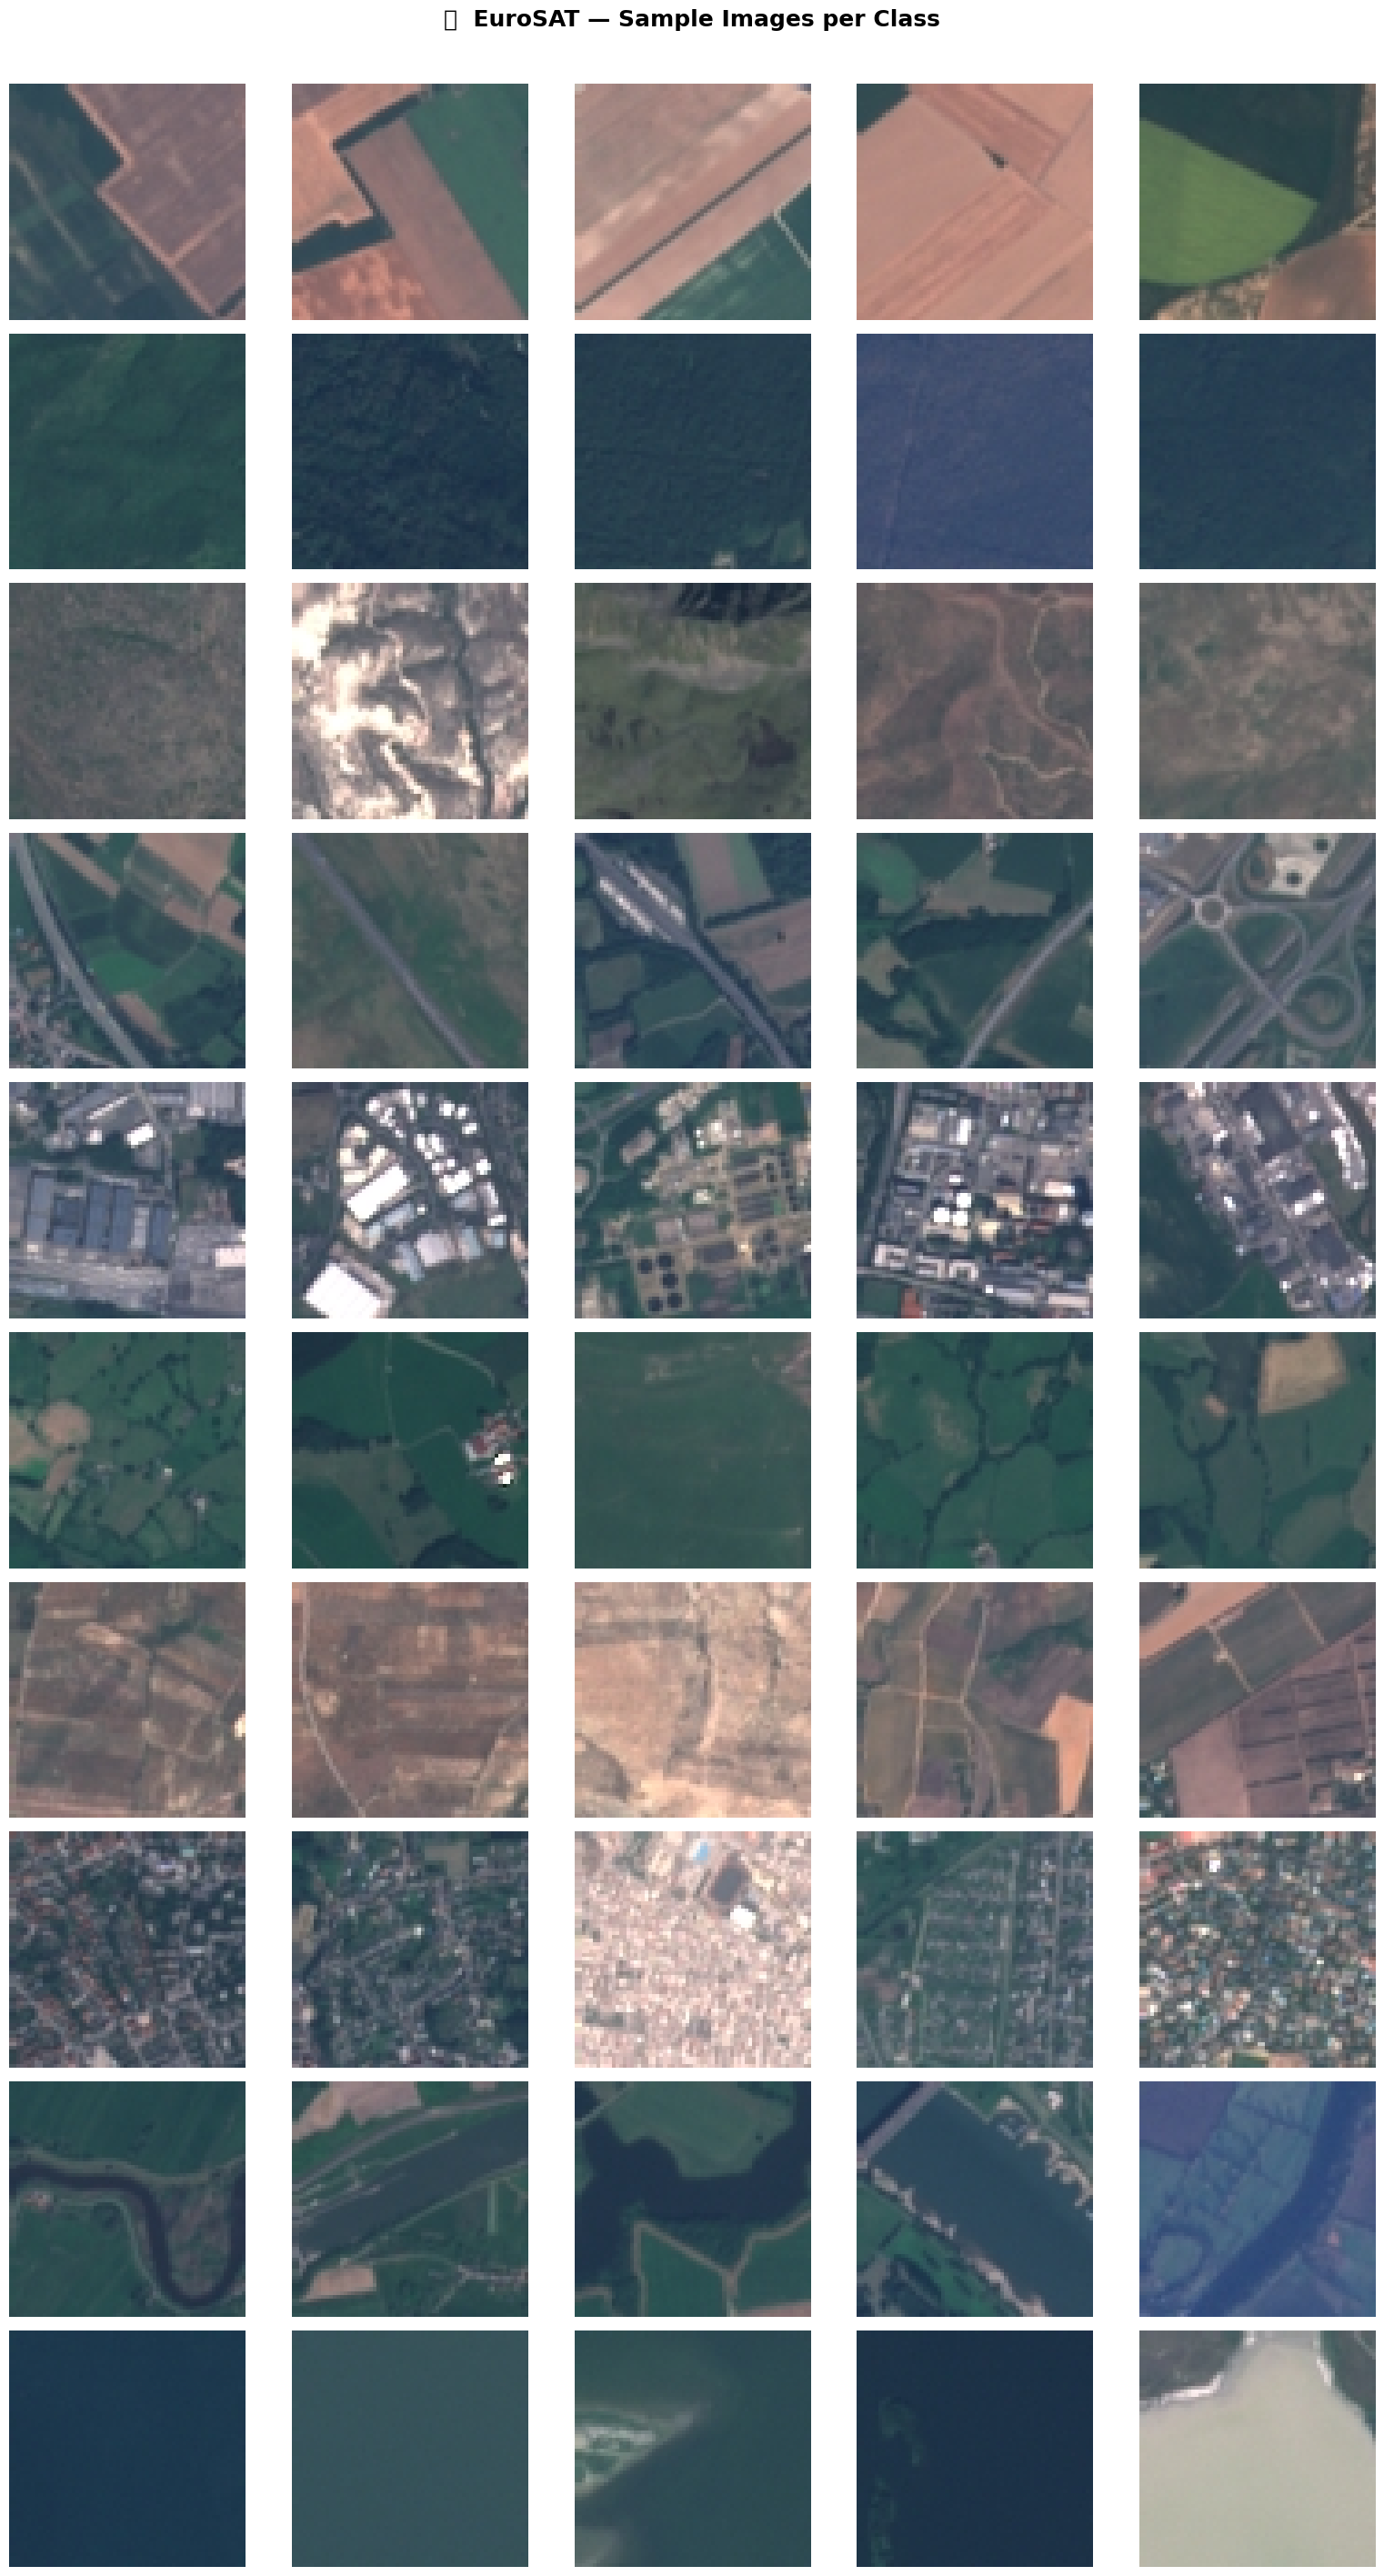

Figure saved: class_samples.png


In [ ]:
#— DATA VISUALIZATION


def load_image(path, size=IMG_SIZE):
    """Load an image from disk and resize it."""
    img = Image.open(str(path)).convert('RGB')
    img = img.resize((size, size))
    return np.array(img)

# ── 4.1 Random Image Grid per Class ───────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(16, NUM_CLASSES * 2.8))
fig.suptitle('🛰️  EuroSAT — Sample Images per Class',
             fontsize=18, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    cls_imgs = list((DATA_DIR / cls).glob('*.jpg')) + \
               list((DATA_DIR / cls).glob('*.png'))
    samples  = random.sample(cls_imgs, min(5, len(cls_imgs)))
    for col, img_path in enumerate(samples):
        ax = axes[row, col]
        ax.imshow(load_image(img_path))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold',
                          rotation=0, labelpad=80, va='center')

plt.tight_layout()
plt.savefig('class_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: class_samples.png")

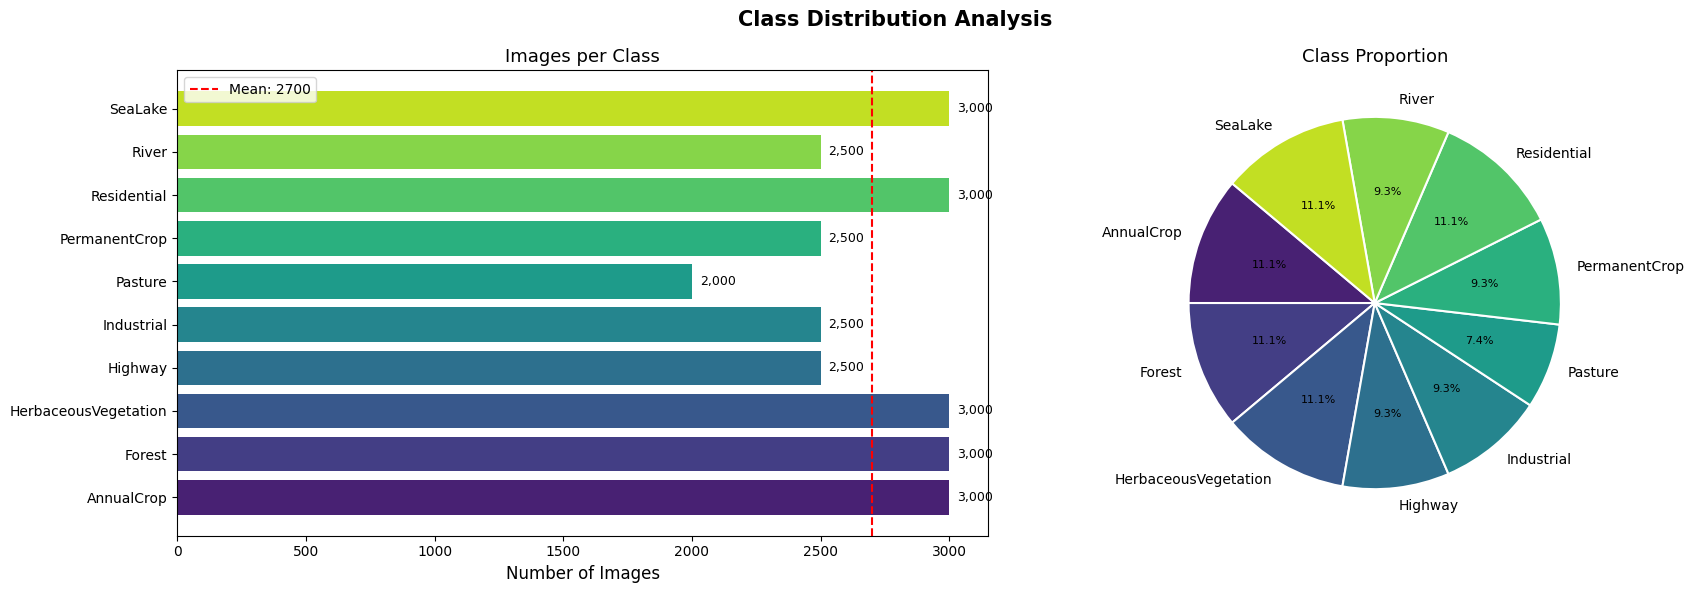

In [ ]:
# ── 4.2 Class Distribution Chart ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Class Distribution Analysis', fontsize=15, fontweight='bold')

counts = [class_counts[c] for c in CLASS_NAMES]
palette = sns.color_palette('viridis', NUM_CLASSES)

# Bar chart
bars = axes[0].barh(CLASS_NAMES, counts, color=palette)
axes[0].set_xlabel('Number of Images', fontsize=12)
axes[0].set_title('Images per Class', fontsize=13)
axes[0].axvline(np.mean(counts), color='red', linestyle='--',
                label=f'Mean: {np.mean(counts):.0f}')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{cnt:,}', va='center', fontsize=9)
axes[0].legend()

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts, labels=CLASS_NAMES, autopct='%1.1f%%',
    colors=palette, startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(8)
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ⚙️ Data Preprocessing & tf.data Pipeline

In [ ]:
# DATA PREPROCESSING & tf.data PIPELINE


AUTOTUNE = tf.data.AUTOTUNE

# ── Image loading function ─────────────────────────────────────
def parse_image(img_path, label):
    """Read, decode, resize, and normalise a single image."""
    img  = tf.io.read_file(img_path)
    img  = tf.image.decode_jpeg(img, channels=3)
    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img  = tf.cast(img, tf.float32) / 255.0   # Normalise to [0, 1]
    return img, label

# ── Build tf.data datasets ────────────────────────────────────
def build_dataset(paths, labels, augment=False, shuffle=False):
    """Create an efficient tf.data.Dataset from file paths."""
    paths_str = [str(p) for p in paths]
    ds = tf.data.Dataset.from_tensor_slices((paths_str, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

print("Dataset pipeline functions defined.")

Dataset pipeline functions defined.


## 6. 🔄 Data Augmentation

**Why Augmentation?**

Satellite images have rotational and reflective symmetry — a forest looks the same whether viewed from north or south. Data augmentation artificially increases dataset diversity by applying random transforms, which:

- Prevents overfitting on the training set
- Forces the model to learn invariant, generalizable features
- Simulates real-world acquisition variability (seasonal, sensor noise)

We use TensorFlow's `tf.image` API for GPU-accelerated augmentation applied on-the-fly during training.

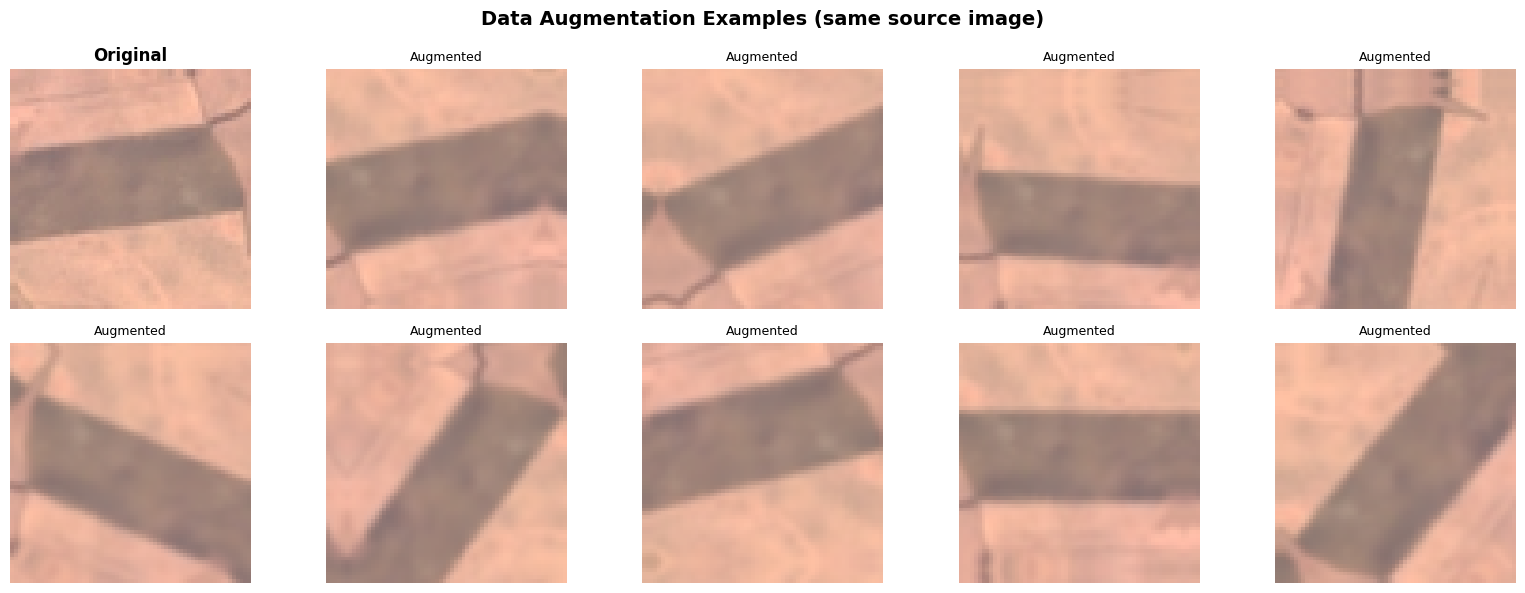

✅ Train / Validation / Test tf.data datasets created.
   Batch size  : 64
   Train steps : 296
   Val   steps : 64
   Test  steps : 64


In [ ]:
# SECTION 6 — DATA AUGMENTATION


# Keras sequential augmentation layer (applied inside the model graph)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

def augment_image(image, label):
    """Apply augmentation pipeline to a single image."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# ── Visualise augmented samples ────────────────────────────────
sample_img = load_image(all_images[0]).astype('float32') / 255.0
sample_t   = tf.expand_dims(sample_img, 0)  # (1, H, W, 3)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Data Augmentation Examples (same source image)',
             fontsize=14, fontweight='bold')

axes[0, 0].imshow(sample_img)   # already float32 ✅
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

aug_axes = [axes[r, c] for r in range(2) for c in range(5)][1:]
for ax in aug_axes:
    aug = data_augmentation(sample_t, training=True)[0]
    aug = tf.cast(aug, tf.float32).numpy()   # ← THE FIX: float16 → float32
    aug = np.clip(aug, 0, 1)
    ax.imshow(aug)
    ax.set_title('Augmented', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Build final datasets ───────────────────────────────────────
train_ds = build_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = build_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = build_dataset(X_test,  y_test,  augment=False, shuffle=False)

print("✅ Train / Validation / Test tf.data datasets created.")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   Train steps : {len(train_ds)}")
print(f"   Val   steps : {len(val_ds)}")
print(f"   Test  steps : {len(test_ds)}")

## 7. 🏗️ Baseline CNN Model

In [ ]:
#  CUSTOM CNN BASELINE


def build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                       num_classes=NUM_CLASSES):
    """
    Custom CNN baseline.
    Architecture: Conv → BN → Pool → Dropout (repeated 4×) → Dense head
    """
    inputs = keras.Input(shape=input_shape, name='input')

    # Augmentation
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.35)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.35)(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           dtype='float32', name='predictions')(x)

    return keras.Model(inputs, outputs, name='baseline_cnn')


baseline_model = build_baseline_cnn()
baseline_model.summary()

# Count parameters
total_params = baseline_model.count_params()
print(f"\n Total parameters: {total_params:,}")

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 8, 8, 256)      │         1,02

 Total params: 723,754 (2.76 MB)

 Trainable params: 721,322 (2.75 MB)

 Non-trainable params: 2,432 (9.50 KB)


 Total parameters: 723,754


In [ ]:
# ── Compile & Train Baseline ───────────────────────────────────

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

base_callbacks = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=6,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('baseline_best.keras',
                           monitor='val_accuracy',
                           save_best_only=True, verbose=0),
]

print("\n🚀 Training Baseline CNN...\n")
t0 = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASE,
    callbacks=base_callbacks,
    verbose=1
)

baseline_train_time = time.time() - t0
print(f"\n Training time: {baseline_train_time/60:.1f} minutes")


🚀 Training Baseline CNN...

Epoch 1/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.4183 - loss: 1.8987 - val_accuracy: 0.1515 - val_loss: 4.8121 - learning_rate: 0.0010
Epoch 2/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.6484 - loss: 1.0063 - val_accuracy: 0.4787 - val_loss: 2.1711 - learning_rate: 0.0010
Epoch 3/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.7147 - loss: 0.8359 - val_accuracy: 0.6866 - val_loss: 1.0651 - learning_rate: 0.0010
Epoch 4/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.7661 - loss: 0.6738 - val_accuracy: 0.6859 - val_loss: 0.9715 - learning_rate: 0.0010
Epoch 5/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.8001 - loss: 0.5794 - val_accuracy: 0.7715 - val_loss: 0.7421 - learning_rate: 0.0010
Epoch 6/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.8253 - loss: 0.5166 - val_accuracy: 0.7886 - val_loss: 0.6488 - learning_rate: 0.0010
Epoch 7/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 47m

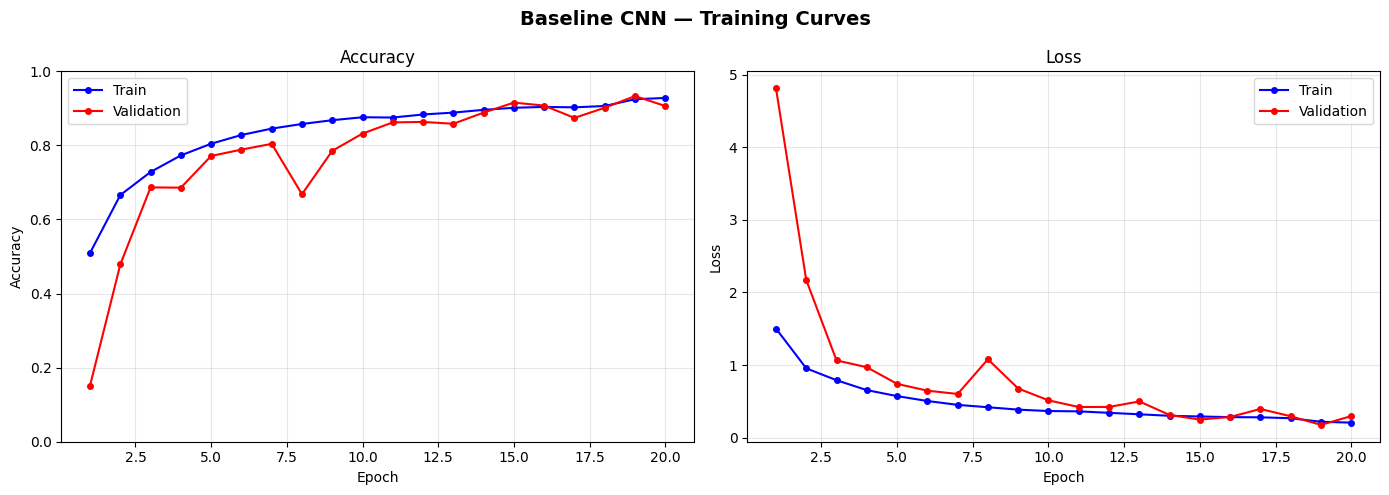

In [ ]:
# ── Learning Curves ────────────────────────────────────────────

def plot_history(history, model_name, save_path=None):
    """Plot accuracy and loss curves from a Keras history object."""
    acc    = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss   = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training Curves',
                 fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs, acc,     'b-o', markersize=4, label='Train')
    axes[0].plot(epochs, val_acc, 'r-o', markersize=4, label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim(0, 1)

    # Loss
    axes[1].plot(epochs, loss,     'b-o', markersize=4, label='Train')
    axes[1].plot(epochs, val_loss, 'r-o', markersize=4, label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_history(baseline_history, 'Baseline CNN', 'baseline_curves.png')

## 8. 🤖 Transfer Learning Models

We train two state-of-the-art pretrained models using a two-stage strategy:

1. **Stage 1 — Feature Extraction:** Freeze all base layers, train only the classification head
2. **Stage 2 — Fine-Tuning:** Unfreeze the top layers of the base, train with a very low learning rate

This is the industry-standard approach for maximizing transfer learning performance.

In [ ]:
#  TRANSFER LEARNING (CORRECTED)


AUTOTUNE = tf.data.AUTOTUNE

def parse_image_raw(img_path, label):
    """Load image WITHOUT normalisation — returns [0, 255] float32."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)   # keep in [0, 255]
    return img, label

def augment_raw(image, label):
    """Augmentation that works on [0, 255] range."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=25.5)   # ~10% of 255
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

def build_dataset_raw(paths, labels, augment=False, shuffle=False):
    """tf.data pipeline returning raw [0,255] images for TL models."""
    paths_str = [str(p) for p in paths]
    ds = tf.data.Dataset.from_tensor_slices((paths_str, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(parse_image_raw, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_raw, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds_tl = build_dataset_raw(X_train, y_train, augment=True,  shuffle=True)
val_ds_tl   = build_dataset_raw(X_val,   y_val,   augment=False, shuffle=False)
test_ds_tl  = build_dataset_raw(X_test,  y_test,  augment=False, shuffle=False)

print(" Raw [0-255] datasets ready for transfer learning.")


# ── Shared callback factory ────────────────────────────────────
def get_tl_callbacks(name, patience_es=6, patience_lr=3):
    return [
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=patience_es,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=patience_lr,
            min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(
            f'{name}_best.keras', monitor='val_accuracy',
            save_best_only=True, verbose=0),
    ]


# ── Generic TL model builder ───────────────────────────────────
def build_tl_model(base_class, preprocess_fn, model_name,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3),
                   num_classes=NUM_CLASSES):
    """
    Correct transfer learning setup:
    - Input: raw [0, 255] float32
    - preprocess_fn maps to model-specific range
    - base called with training=False (freezes BN stats)
    """
    inputs = keras.Input(shape=input_shape)

    # Model-specific preprocessing (handles [0,255] → correct range)
    x = preprocess_fn(inputs)

    # Instantiate base with fixed input shape
    base = base_class(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = False

    # training=False: critical — keeps BN in inference mode while frozen
    x = base(x, training=False)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           dtype='float32')(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model, base

 Raw [0-255] datasets ready for transfer learning.


In [ ]:
# 8.1 — EfficientNetB3 (upgrade from B0 — better for 64px)
# ============================================================
# EfficientNetB3 handles small images better than B0 and is
# still fast enough on T4 GPU.

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import (
    preprocess_input as eff_preprocess
)

print("\n" + "="*55)
print("  MODEL 1: EfficientNetB3")
print("="*55)

eff_model, eff_base = build_tl_model(
    EfficientNetB3, eff_preprocess, 'efficientnetb3'
)

# ── Stage 1: Head-only training ────────────────────────────────
eff_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(p.numpy().size for p in eff_model.trainable_weights)
print(f"Stage 1 trainable params: {trainable:,}")
print("\n🚀 EfficientNetB3 — Stage 1: Feature Extraction\n")

t0 = time.time()
eff_h1 = eff_model.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=20,
    callbacks=get_tl_callbacks('effb3_s1', patience_es=5, patience_lr=2),
    verbose=1
)

# ── Stage 2: Fine-tune top layers ─────────────────────────────
# Unfreeze last 30 layers of EfficientNetB3
eff_base.trainable = True
for layer in eff_base.layers[:-30]:
    layer.trainable = False

# Use very small LR to avoid destroying pretrained weights
eff_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable_ft = sum(p.numpy().size for p in eff_model.trainable_weights)
print(f"\nStage 2 trainable params: {trainable_ft:,}")
print("\n🔧 EfficientNetB3 — Stage 2: Fine-Tuning\n")

eff_h2 = eff_model.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=20,
    callbacks=get_tl_callbacks('effb3_s2', patience_es=6, patience_lr=3),
    verbose=1
)

train_times['EfficientNetB3'] = time.time() - t0
histories['EfficientNetB3']   = {'stage1': eff_h1, 'stage2': eff_h2}
print(f"\n  EfficientNetB3 total: {train_times['EfficientNetB3']/60:.1f} min")



  MODEL 1: EfficientNetB3
Stage 1 trainable params: 921,866

🚀 EfficientNetB3 — Stage 1: Feature Extraction

Epoch 1/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 154s 337ms/step - accuracy: 0.7208 - loss: 0.8975 - val_accuracy: 0.8743 - val_loss: 0.3640 - learning_rate: 0.0010
Epoch 2/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8384 - loss: 0.4955 - val_accuracy: 0.8943 - val_loss: 0.3074 - learning_rate: 0.0010
Epoch 3/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8582 - loss: 0.4176 - val_accuracy: 0.8946 - val_loss: 0.2926 - learning_rate: 0.0010
Epoch 4/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8648 - loss: 0.3991 - val_accuracy: 0.9111 - val_loss: 0.2658 - learning_rate: 0.0010
Epoch 5/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8752 - loss: 0.3638 - val_accuracy: 0.9082 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 6/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8774 - loss: 0.3638 - val_accuracy: 0.9151 - val_loss: 

In [ ]:

# 8.2 — MobileNetV2 (fast, strong on small images)
# ============================================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess
)

print("\n" + "="*55)
print("  MODEL 2: MobileNetV2")
print("="*55)

mob_model, mob_base = build_tl_model(
    MobileNetV2, mobilenet_preprocess, 'mobilenetv2'
)

mob_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 MobileNetV2 — Stage 1: Feature Extraction\n")

t0 = time.time()
mob_h1 = mob_model.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=20,
    callbacks=get_tl_callbacks('mob_s1', patience_es=5, patience_lr=2),
    verbose=1
)

# Fine-tune last 30 layers
mob_base.trainable = True
for layer in mob_base.layers[:-30]:
    layer.trainable = False

mob_model.compile(
    optimizer=keras.optimizers.Adam(5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔧 MobileNetV2 — Stage 2: Fine-Tuning\n")

mob_h2 = mob_model.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=20,
    callbacks=get_tl_callbacks('mob_s2', patience_es=6, patience_lr=3),
    verbose=1
)

train_times['MobileNetV2'] = time.time() - t0
histories['MobileNetV2']   = {'stage1': mob_h1, 'stage2': mob_h2}
print(f"\n⏱️  MobileNetV2 total: {train_times['MobileNetV2']/60:.1f} min")



  MODEL 2: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 MobileNetV2 — Stage 1: Feature Extraction

Epoch 1/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 102s 238ms/step - accuracy: 0.6626 - loss: 1.0784 - val_accuracy: 0.8453 - val_loss: 0.4697 - learning_rate: 0.0010
Epoch 2/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8101 - loss: 0.5779 - val_accuracy: 0.8609 - val_loss: 0.4071 - learning_rate: 0.0010
Epoch 3/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8424 - loss: 0.4880 - val_accuracy: 0.8688 - val_loss: 0.3736 - learning_rate: 0.0010
Epoch 4/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8577 - loss: 0.4294 - val_accuracy: 0.8720 - val_loss: 0.3797 - learning_rate: 0.0010
Epoch 5/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8687 - loss: 0.3968 - val_accuracy: 0.8740 - val_loss: 0.3650 - learning_rate: 0.0010
Epoch 6/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8638 - loss: 0.4022 - val_accuracy: 0.8715 - v

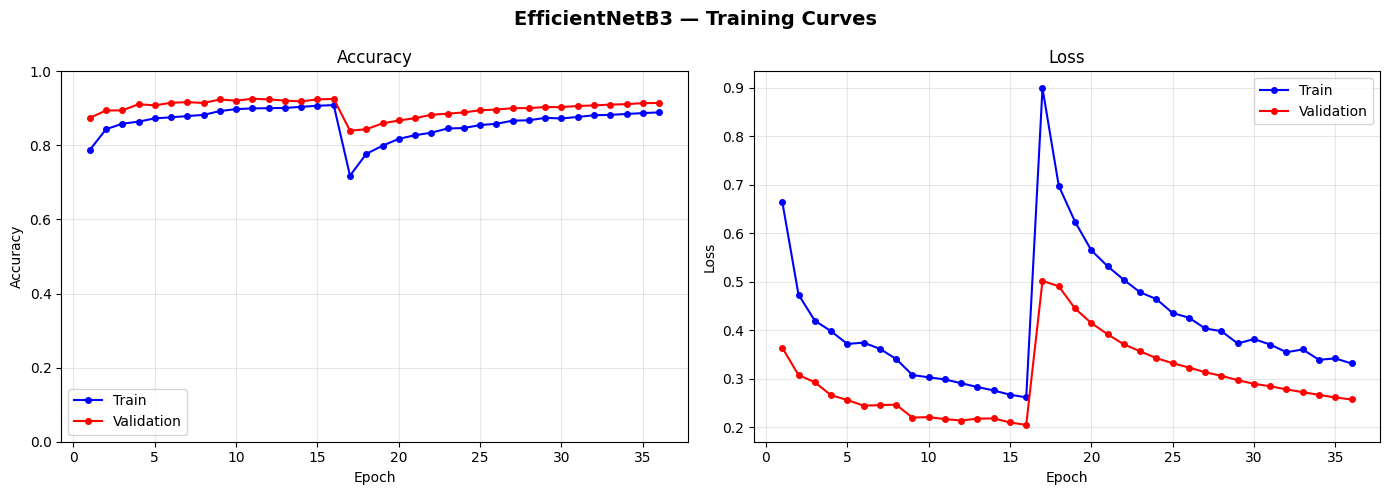

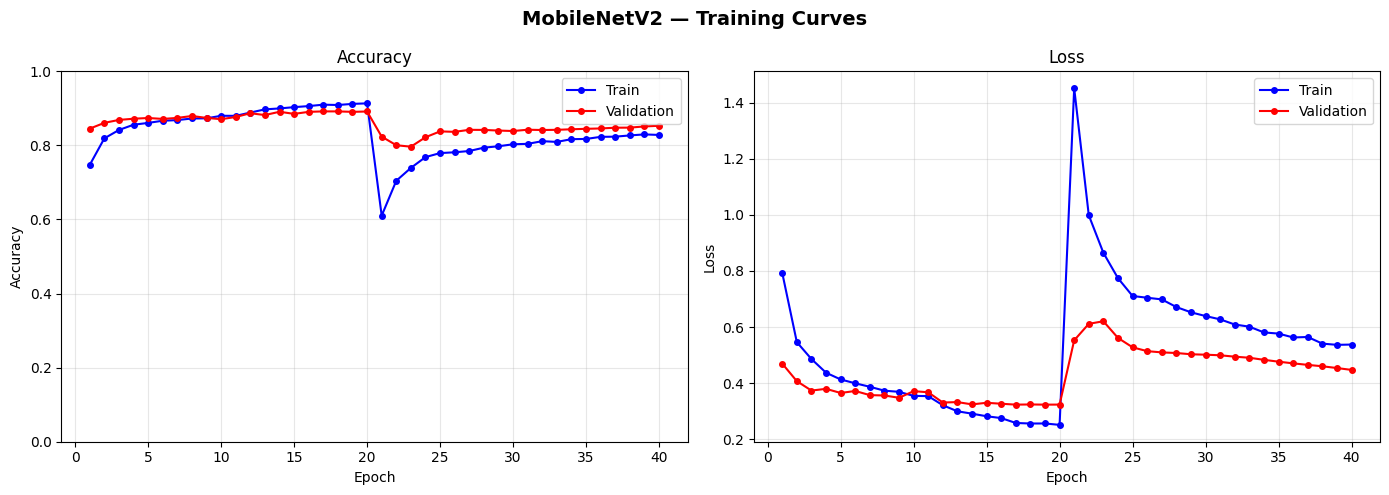


 Transfer learning complete.


In [ ]:
# ── Plot both models ───────────────────────────────────────────
for name, h1, h2 in [('EfficientNetB3', eff_h1, eff_h2),
                      ('MobileNetV2',    mob_h1, mob_h2)]:
    plot_history(MergedHistory(h1, h2), name,
                 f'{name.lower()}_curves.png')

print("\n Transfer learning complete.")


## 9. 📈 Model Evaluation

Running evaluation on test set...


  Evaluating: Baseline CNN
  Accuracy  : 0.9311  (93.11%)
  Precision : 0.9344
  Recall    : 0.9311
  F1-Score  : 0.9310

  Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.9718    0.9200    0.9452       450
              Forest     0.8733    0.9956    0.9304       450
HerbaceousVegetation     0.8758    0.9089    0.8920       450
             Highway     0.9656    0.8987    0.9309       375
          Industrial     0.9664    0.9200    0.9426       375
             Pasture     0.9556    0.9333    0.9444       300
       PermanentCrop     0.9569    0.8293    0.8886       375
         Residential     0.9201    0.9978    0.9574       450
               River     0.8771    0.9707    0.9215       375
             SeaLake     0.9928    0.9200    0.9550       450

            accuracy                         0.9311      4050
           macro avg     0.9355    0.9294    0.9308      4050
        w

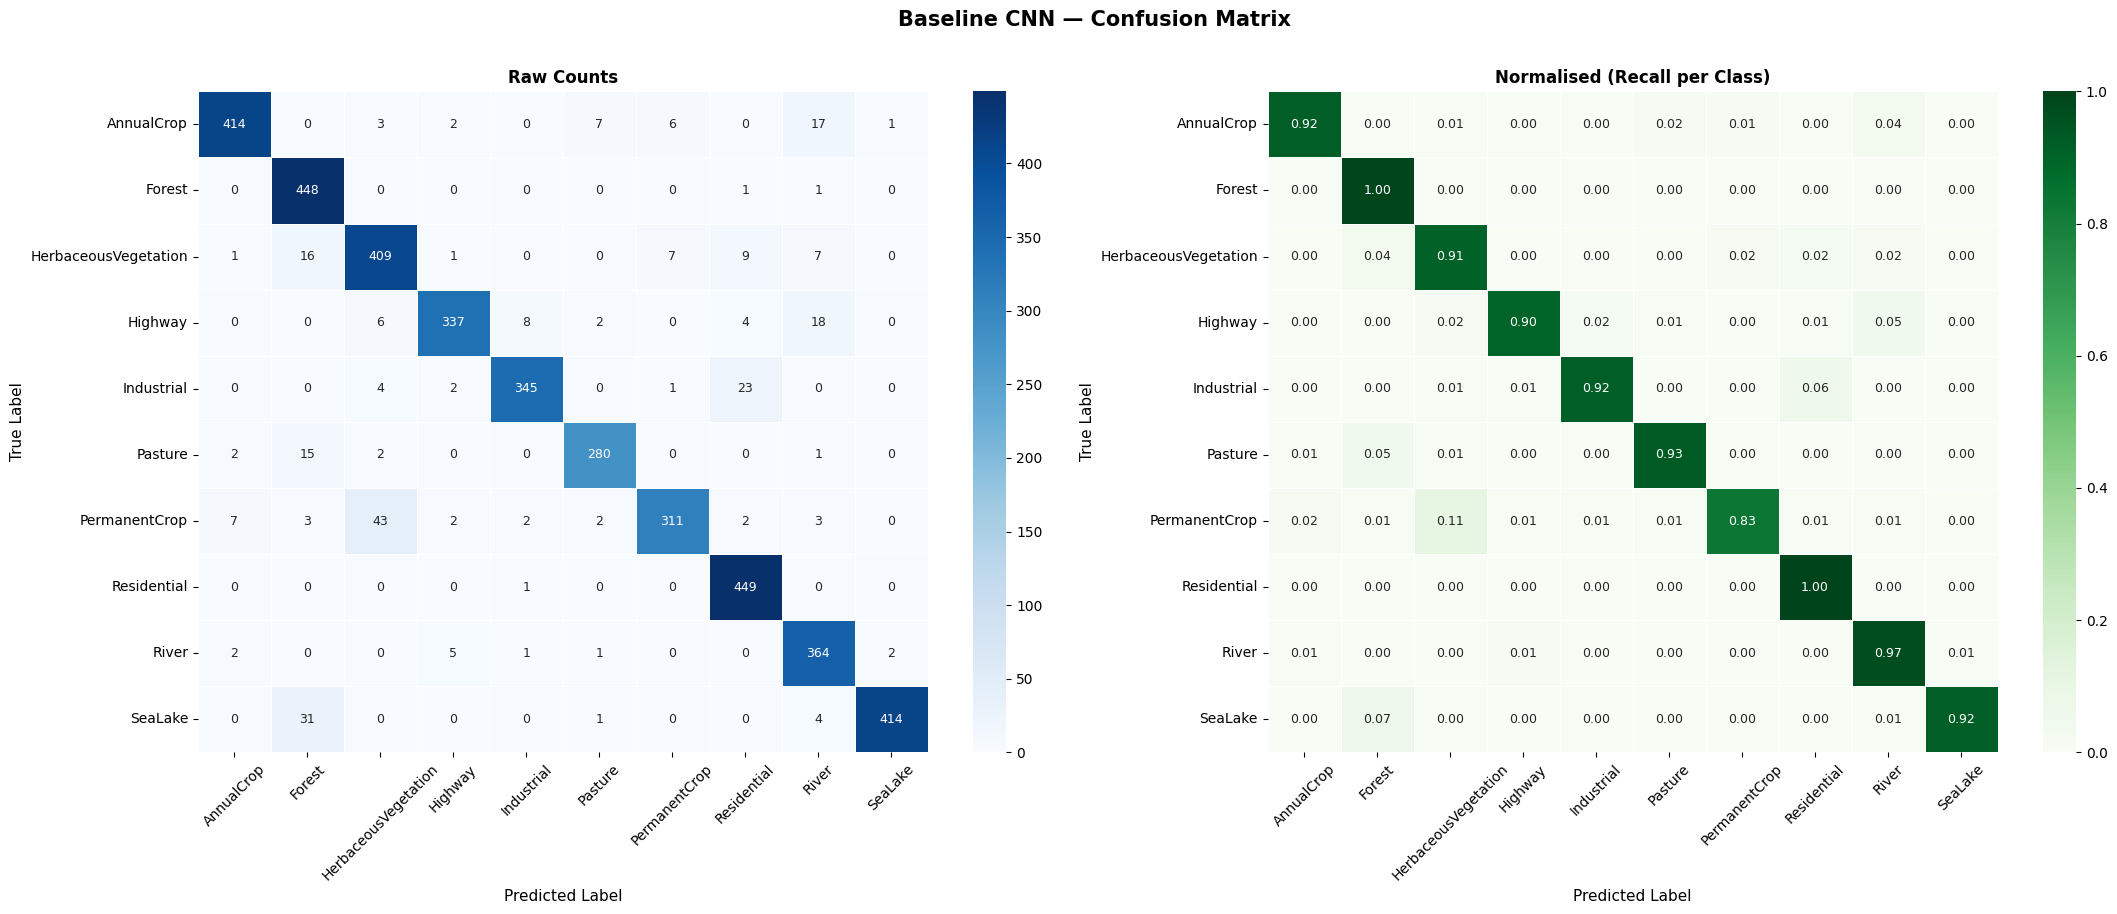


  Evaluating: EfficientNetB3
  Accuracy  : 0.9183  (91.83%)
  Precision : 0.9182
  Recall    : 0.9183
  F1-Score  : 0.9179

  Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.8966    0.9244    0.9103       450
              Forest     0.9355    0.9667    0.9508       450
HerbaceousVegetation     0.9087    0.9067    0.9077       450
             Highway     0.8579    0.8693    0.8636       375
          Industrial     0.9344    0.9493    0.9418       375
             Pasture     0.9211    0.8567    0.8877       300
       PermanentCrop     0.8814    0.8320    0.8560       375
         Residential     0.9322    0.9778    0.9544       450
               River     0.9093    0.8827    0.8958       375
             SeaLake     0.9910    0.9733    0.9821       450

            accuracy                         0.9183      4050
           macro avg     0.9168    0.9139    0.9150      4050
        weighted avg     0.9182    0.9183 

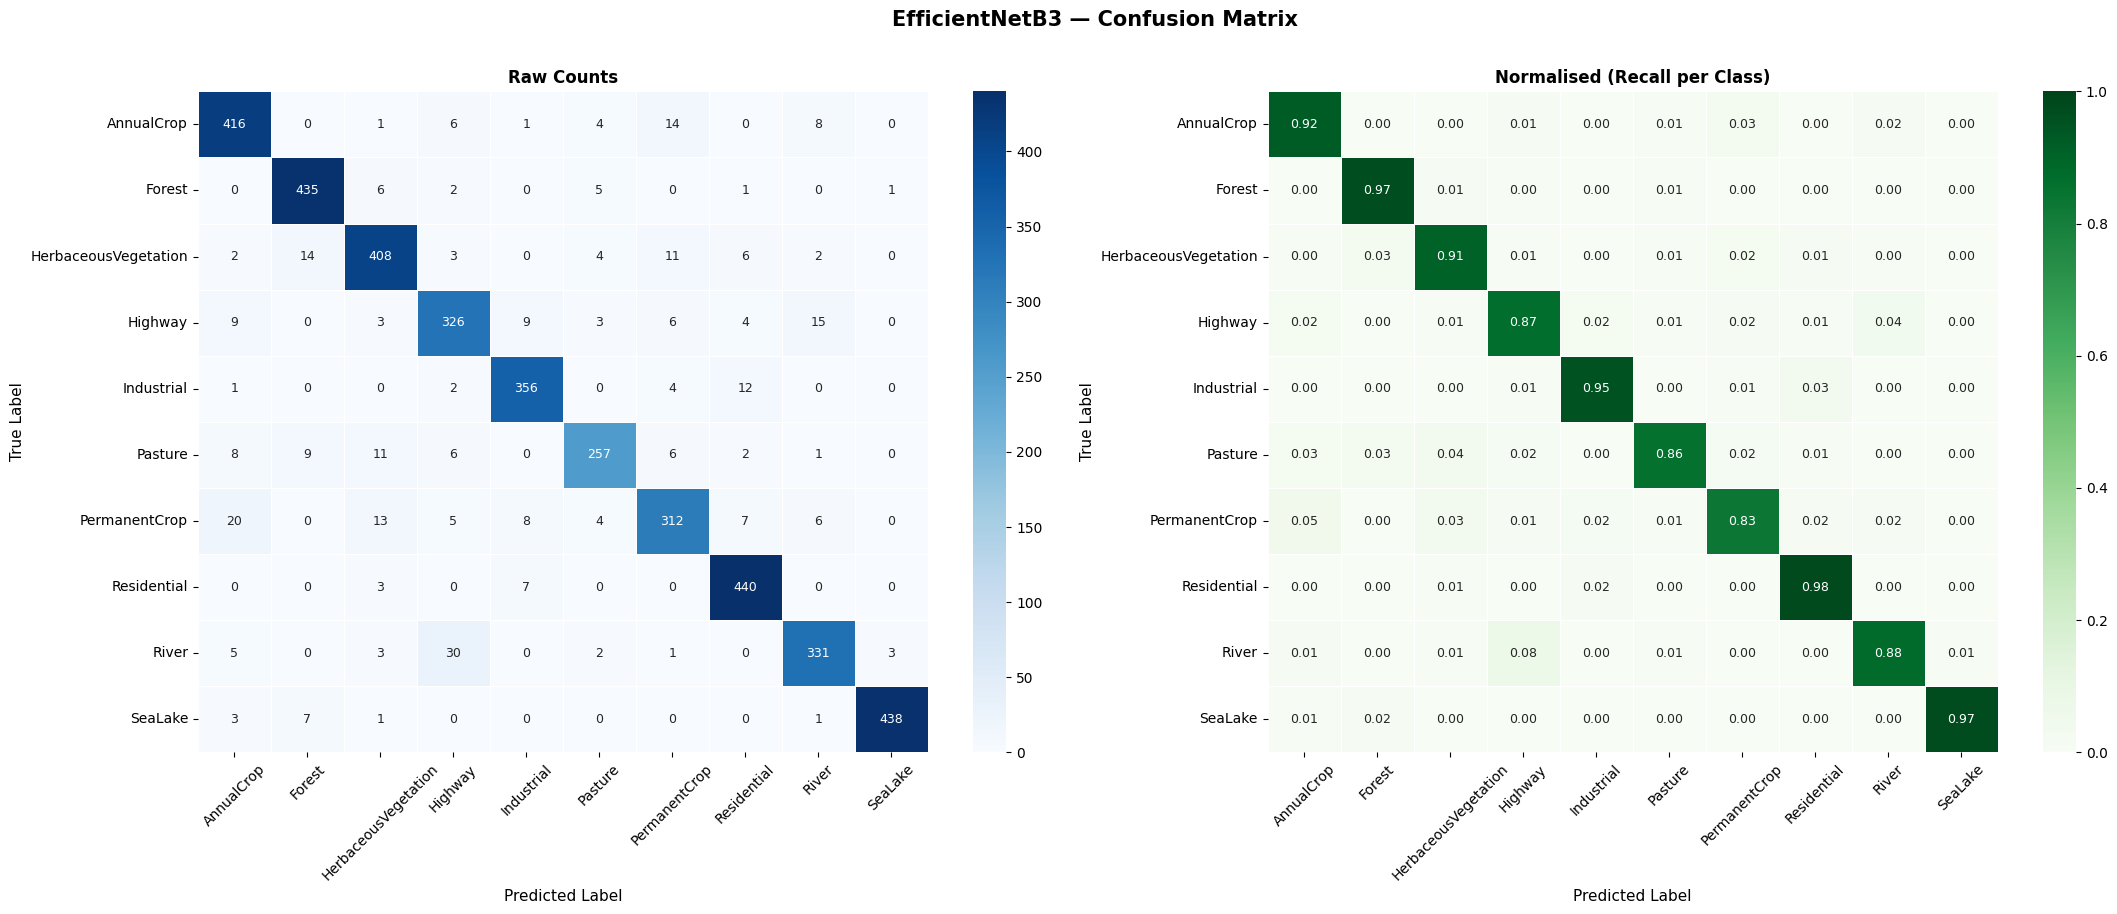


  Evaluating: MobileNetV2
  Accuracy  : 0.8610  (86.10%)
  Precision : 0.8613
  Recall    : 0.8610
  F1-Score  : 0.8608

  Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.9213    0.9111    0.9162       450
              Forest     0.8717    0.8911    0.8813       450
HerbaceousVegetation     0.7859    0.8400    0.8120       450
             Highway     0.7963    0.8133    0.8047       375
          Industrial     0.9182    0.9280    0.9231       375
             Pasture     0.8255    0.7567    0.7896       300
       PermanentCrop     0.8250    0.7920    0.8082       375
         Residential     0.8843    0.9000    0.8921       450
               River     0.8264    0.8000    0.8130       375
             SeaLake     0.9327    0.9244    0.9286       450

            accuracy                         0.8610      4050
           macro avg     0.8587    0.8557    0.8569      4050
        weighted avg     0.8613    0.8610    

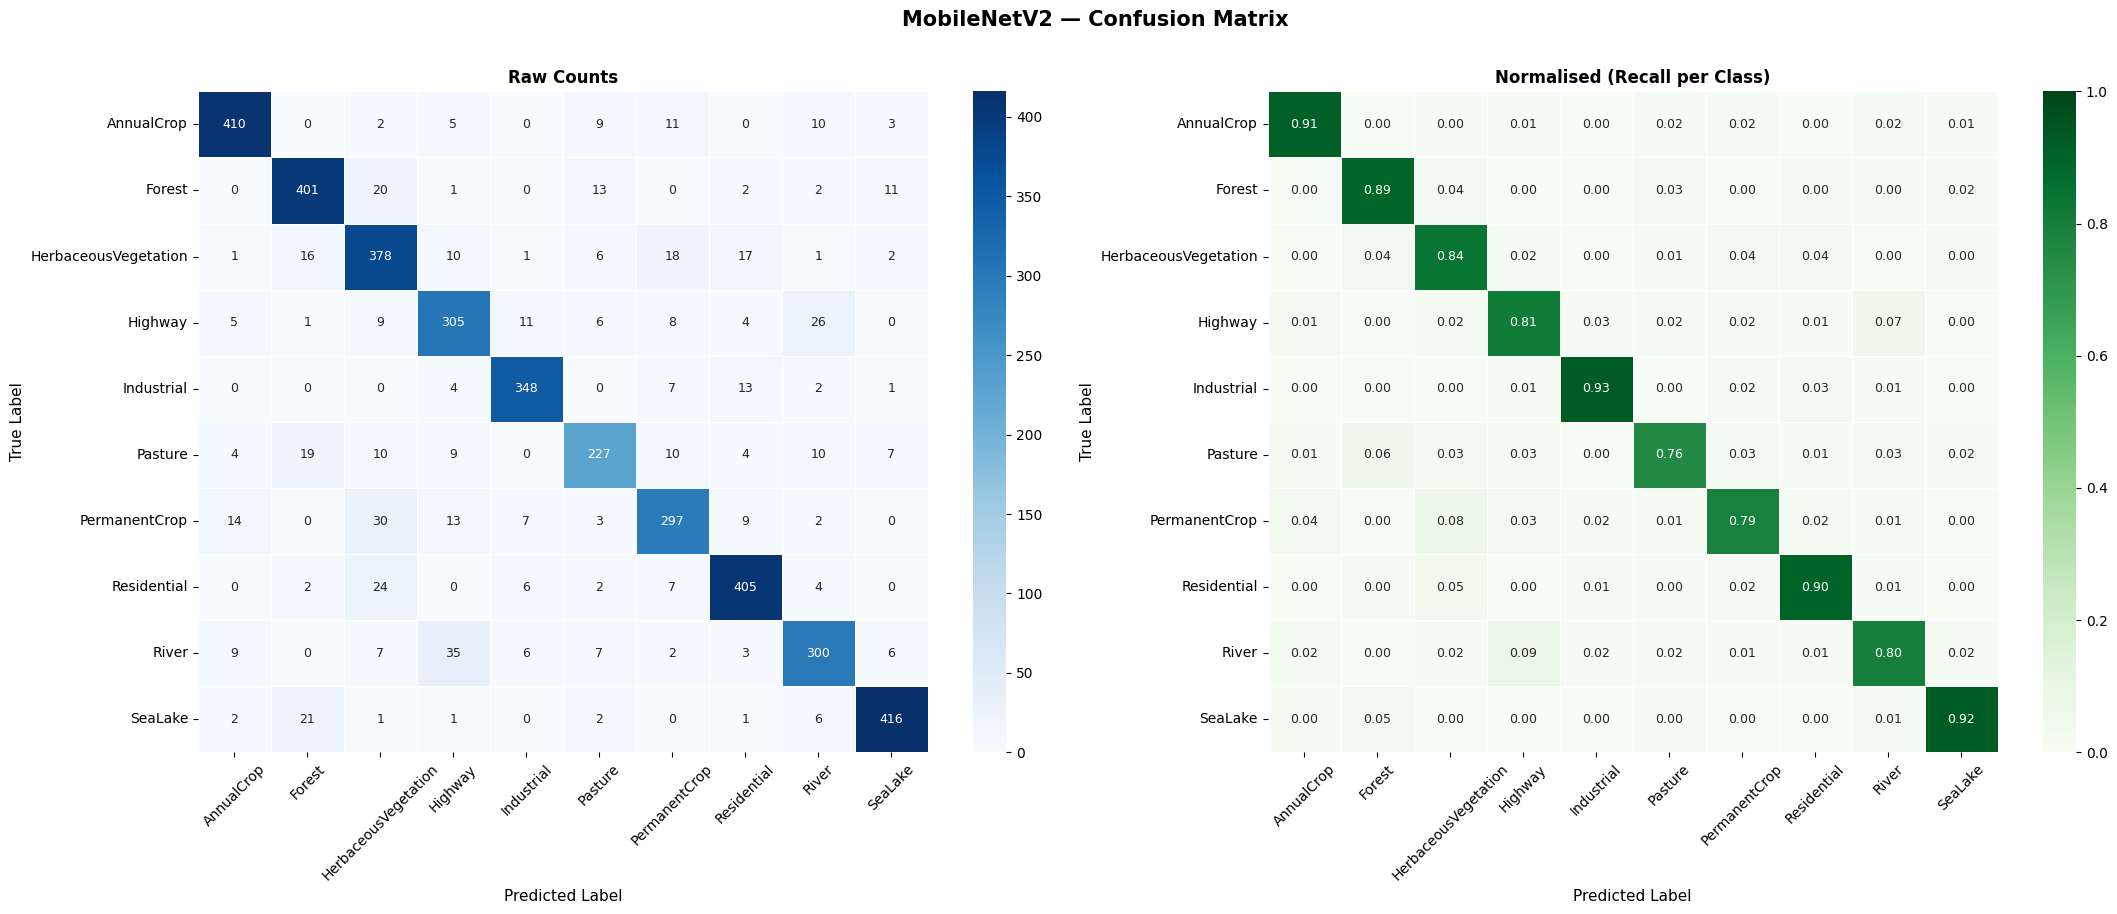

In [ ]:
#  — COMPREHENSIVE MODEL EVALUATION


def evaluate_model(model, dataset, model_name, class_names):
    """
    Full evaluation: accuracy, precision, recall, F1,
    confusion matrix, and classification report.
    """
    print(f"\n{'='*60}")
    print(f"  Evaluating: {model_name}")
    print(f"{'='*60}")

    # Gather predictions batch by batch
    y_true, y_pred_probs = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred_probs.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # ── Metrics ───────────────────────────────────────────────
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)

    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")

    # ── Per-class classification report ───────────────────────
    print("\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names,
                                 digits=4))

    # ── Confusion matrix ──────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)

    # Normalised version (shows % per true class)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle(f'{model_name} — Confusion Matrix',
                 fontsize=15, fontweight='bold', y=1.01)

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=axes[0], annot_kws={'size': 9})
    axes[0].set_title('Raw Counts', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=11)
    axes[0].set_xlabel('Predicted Label', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    # Normalised (recall per class)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=axes[1], vmin=0, vmax=1,
                annot_kws={'size': 9})
    axes[1].set_title('Normalised (Recall per Class)', fontsize=12,
                       fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=11)
    axes[1].set_xlabel('Predicted Label', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_')
    plt.savefig(f'{safe_name}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'accuracy':      acc,
        'precision':     prec,
        'recall':        rec,
        'f1':            f1,
        'y_true':        y_true,
        'y_pred':        y_pred,
        'y_pred_probs':  np.array(y_pred_probs),
        'conf_matrix':   cm,
    }


# ── Evaluate all models on their correct test dataset ─────────
#   baseline_model  → test_ds     (normalised [0,1])
#   eff_model       → test_ds_tl  (raw [0,255])
#   mob_model       → test_ds_tl  (raw [0,255])

print("Running evaluation on test set...\n")

results['Baseline CNN']    = evaluate_model(
    baseline_model, test_ds,    'Baseline CNN',    CLASS_NAMES)

results['EfficientNetB3']  = evaluate_model(
    eff_model,      test_ds_tl, 'EfficientNetB3',  CLASS_NAMES)

results['MobileNetV2']     = evaluate_model(
    mob_model,      test_ds_tl, 'MobileNetV2',     CLASS_NAMES)

## 10. 📊 Visual Model Comparison

  Removing stale result: 'ResNet50'

✅ Comparing models: ['Baseline CNN', 'EfficientNetB3', 'MobileNetV2']

📋 Model Comparison Table:
───────────────────────────────────────────────────────────────────────────
         Model Accuracy Precision Recall F1-Score Params (M) Train Time (min)
  Baseline CNN   0.9311    0.9344 0.9311   0.9310      0.72M              4.7
EfficientNetB3   0.9183    0.9182 0.9183   0.9179     11.71M             10.0
   MobileNetV2   0.8610    0.8613 0.8610   0.8608      3.05M              7.6
───────────────────────────────────────────────────────────────────────────

🏆 Best model : Baseline CNN
   Accuracy   : 0.9311  (93.11%)
   F1-Score   : 0.9310


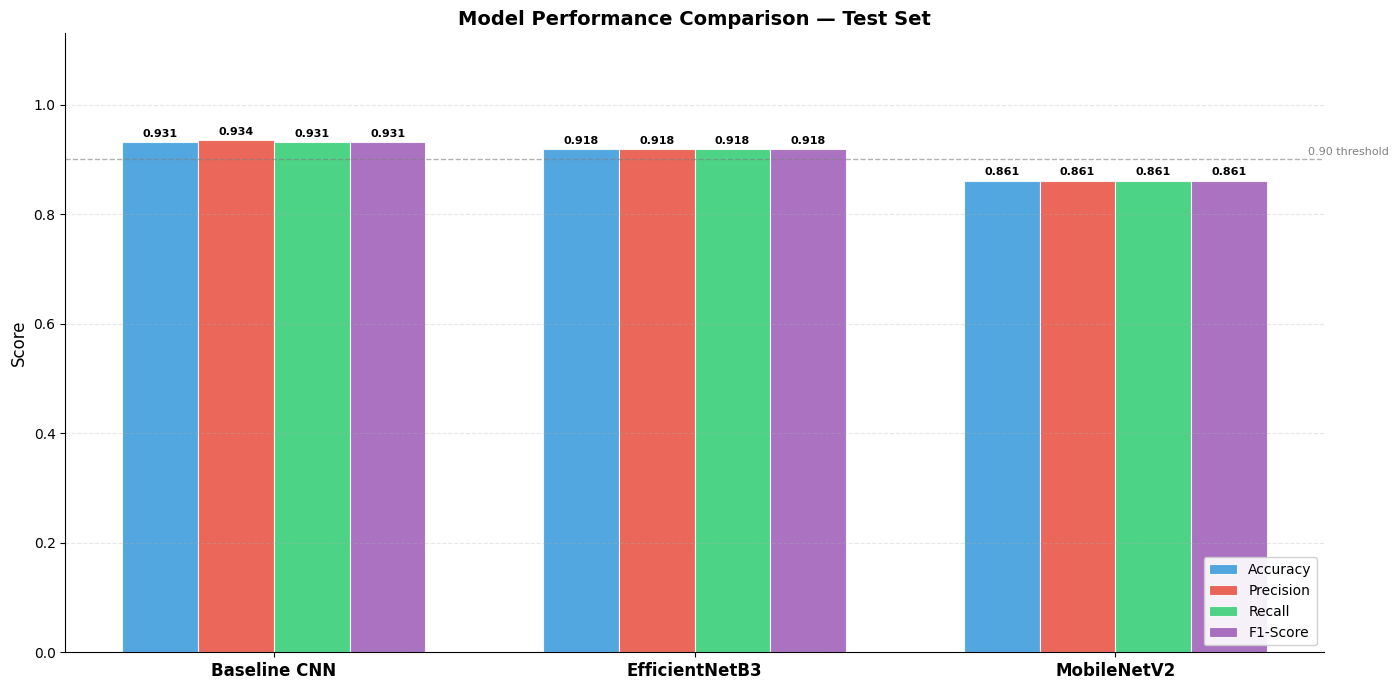

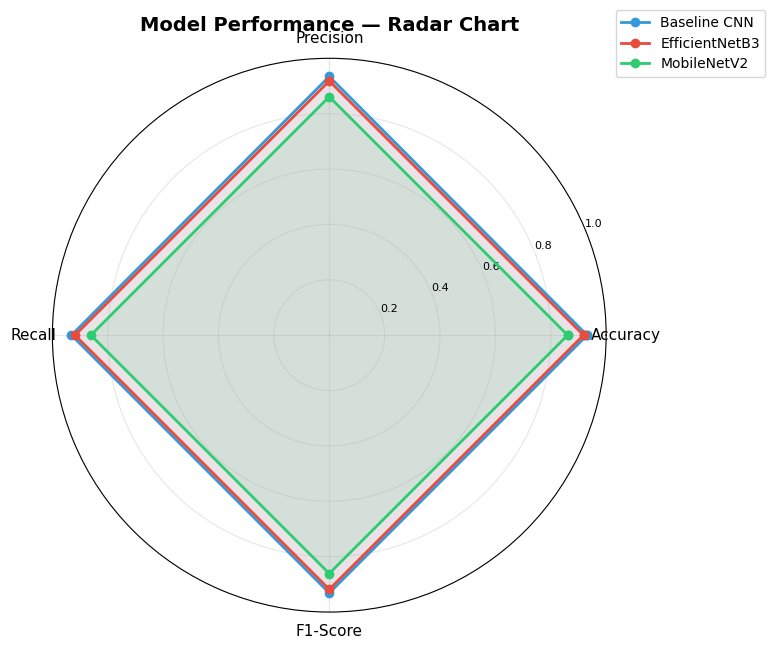

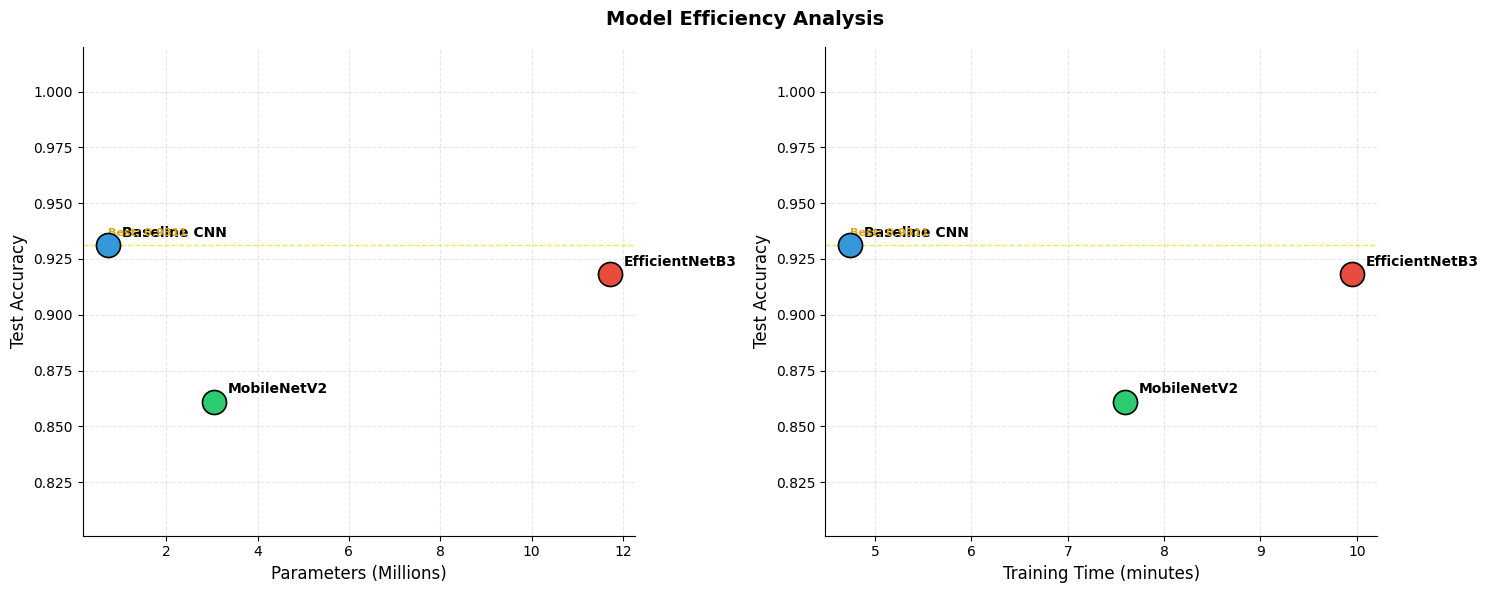

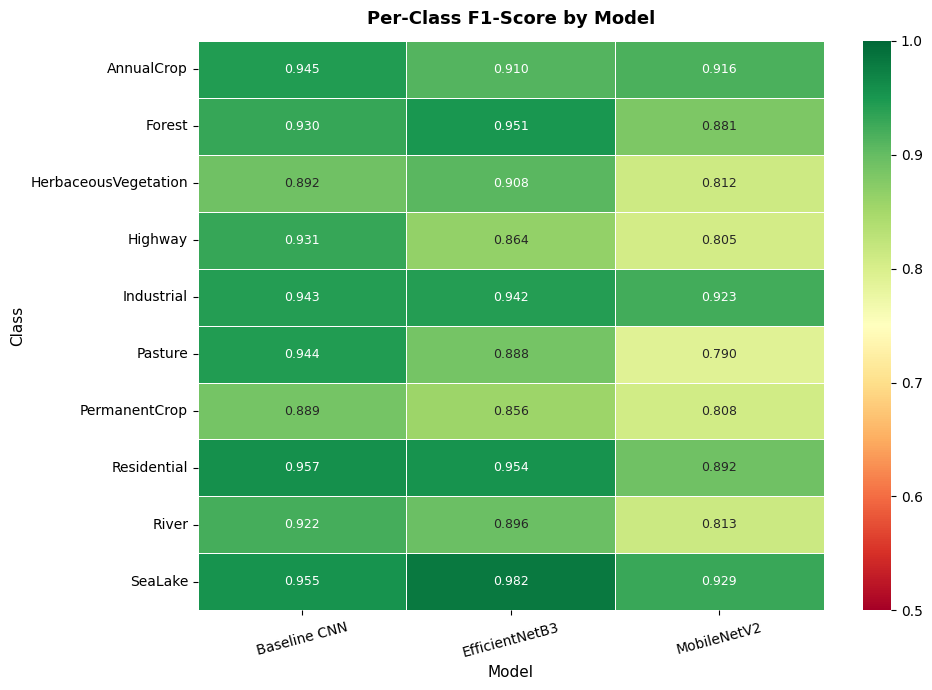

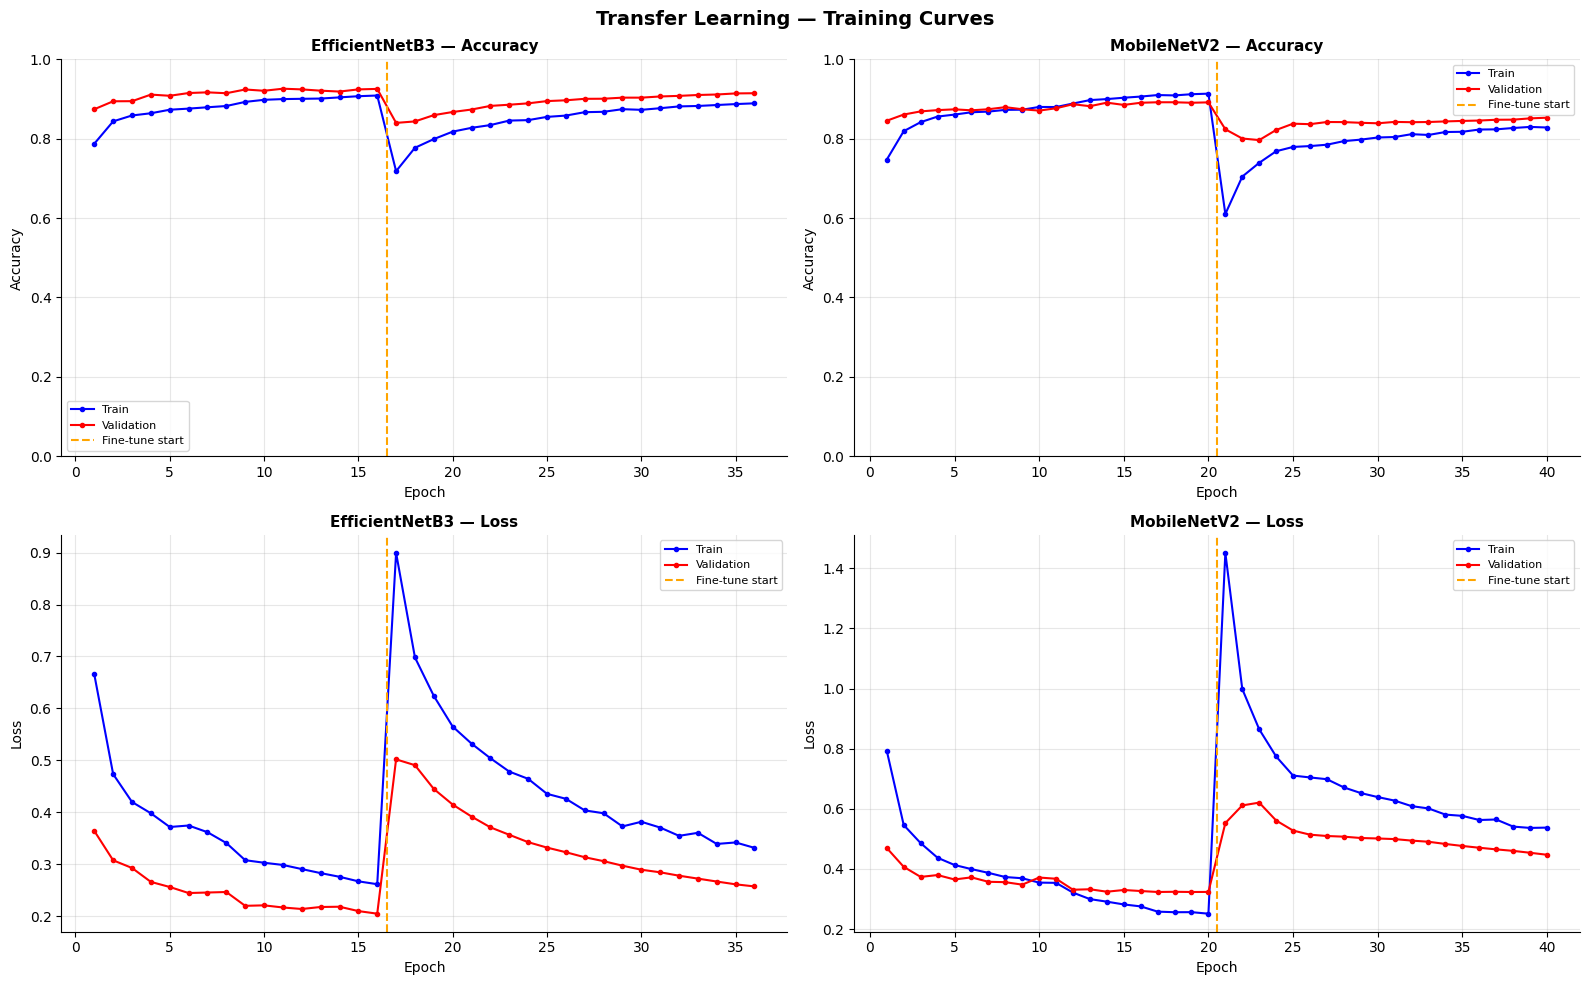

In [ ]:
# — MODEL COMPARISON CHARTS


# ── Clean stale entries from failed/interrupted runs ──────────
valid_models = {'Baseline CNN', 'EfficientNetB3', 'MobileNetV2'}
stale_keys   = [k for k in results if k not in valid_models]
for k in stale_keys:
    print(f"  Removing stale result: '{k}'")
    del results[k]

# ── Map name → model object (single source of truth) ──────────
model_objects = {
    'Baseline CNN':   baseline_model,
    'EfficientNetB3': eff_model,
    'MobileNetV2':    mob_model,
}

# Only keep models that exist in BOTH dicts
model_names = [m for m in model_objects if m in results]
print(f"\n✅ Comparing models: {model_names}\n")

# ── Extract metrics ────────────────────────────────────────────
accuracies   = [results[m]['accuracy']  for m in model_names]
precisions   = [results[m]['precision'] for m in model_names]
recalls      = [results[m]['recall']    for m in model_names]
f1_scores    = [results[m]['f1']        for m in model_names]
param_counts = [model_objects[m].count_params() for m in model_names]

time_lookup  = {
    'Baseline CNN':   baseline_train_time,
    'EfficientNetB3': train_times.get('EfficientNetB3', 0),
    'MobileNetV2':    train_times.get('MobileNetV2', 0),
}
times_min = [time_lookup[m] / 60 for m in model_names]

# ── Comparison Table ───────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Model':            model_names,
    'Accuracy':         [f"{a:.4f}" for a in accuracies],
    'Precision':        [f"{p:.4f}" for p in precisions],
    'Recall':           [f"{r:.4f}" for r in recalls],
    'F1-Score':         [f"{f:.4f}" for f in f1_scores],
    'Params (M)':       [f"{p/1e6:.2f}M" for p in param_counts],
    'Train Time (min)': [f"{t:.1f}" for t in times_min],
})

print("📋 Model Comparison Table:")
print("─" * 75)
print(comparison_df.to_string(index=False))
print("─" * 75)

best_idx        = accuracies.index(max(accuracies))
best_model_name = model_names[best_idx]
print(f"\n🏆 Best model : {best_model_name}")
print(f"   Accuracy   : {max(accuracies):.4f}  ({max(accuracies)*100:.2f}%)")
print(f"   F1-Score   : {f1_scores[best_idx]:.4f}")

# ── 1. Grouped Bar Chart ───────────────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_vals = [accuracies, precisions, recalls, f1_scores]
palette     = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

n_models  = len(model_names)
n_metrics = len(metrics)
width     = 0.18
x         = np.arange(n_models)

fig, ax = plt.subplots(figsize=(14, 7))

for i, (metric, vals, color) in enumerate(zip(metrics, metric_vals, palette)):
    bars = ax.bar(x + i * width, vals, width,
                  label=metric, color=color,
                  alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + 0.006, f'{h:.3f}',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xticks(x + width * (n_metrics - 1) / 2)
ax.set_xticklabels(model_names, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.13)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Test Set',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax.text(n_models - 0.08, 0.905, '0.90 threshold',
        ha='right', va='bottom', fontsize=8, color='gray')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Radar / Spider Chart ────────────────────────────────────
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
angles        = np.linspace(0, 2 * np.pi, len(radar_metrics),
                             endpoint=False).tolist()
angles       += angles[:1]   # close polygon

model_colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_title('Model Performance — Radar Chart',
             fontsize=14, fontweight='bold', pad=20)

for mn, color in zip(model_names, model_colors):
    vals  = [results[mn]['accuracy'],  results[mn]['precision'],
             results[mn]['recall'],    results[mn]['f1']]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=mn)
    ax.fill(angles, vals, alpha=0.10, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Efficiency Scatter: Accuracy vs Params & Train Time ────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Efficiency Analysis', fontsize=14, fontweight='bold')

scatter_x = {
    'Parameters (Millions)':    [p / 1e6 for p in param_counts],
    'Training Time (minutes)':  times_min,
}

for ax, (xlabel, xvals) in zip(axes, scatter_x.items()):
    for mn, xv, acc, color in zip(model_names, xvals,
                                   accuracies, model_colors):
        ax.scatter(xv, acc, s=300, color=color, zorder=5,
                   edgecolors='black', linewidth=1.2)
        ax.annotate(mn, (xv, acc),
                    textcoords='offset points', xytext=(10, 6),
                    fontsize=10, fontweight='bold')

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Test Accuracy', fontsize=12)
    ax.set_ylim(max(0, min(accuracies) - 0.06), 1.02)
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    ax.axhline(max(accuracies), color='gold',
               linestyle='--', alpha=0.7, linewidth=1)
    ax.text(min(xvals), max(accuracies) + 0.004,
            f'Best: {max(accuracies):.4f}',
            fontsize=8, color='goldenrod', fontweight='bold')

plt.tight_layout()
plt.savefig('efficiency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Per-class F1-Score Heatmap ─────────────────────────────
per_class_f1 = {}
for mn in model_names:
    y_t = results[mn]['y_true']
    y_p = results[mn]['y_pred']
    per_class_f1[mn] = f1_score(
        y_t, y_p,
        average=None,
        labels=list(range(NUM_CLASSES)),
        zero_division=0
    )

f1_df = pd.DataFrame(per_class_f1, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.5,
            ax=ax, annot_kws={'size': 9})
ax.set_title('Per-Class F1-Score by Model',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Class', fontsize=11)
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Training Curves Side-by-Side ───────────────────────────
tl_models = {
    'EfficientNetB3': (eff_h1, eff_h2),
    'MobileNetV2':    (mob_h1, mob_h2),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Transfer Learning — Training Curves',
             fontsize=14, fontweight='bold')

for col, (mn, (h1, h2)) in enumerate(tl_models.items()):
    acc_all     = h1.history['accuracy']     + h2.history['accuracy']
    val_acc_all = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss_all    = h1.history['loss']         + h2.history['loss']
    val_loss_all= h1.history['val_loss']     + h2.history['val_loss']
    epochs      = range(1, len(acc_all) + 1)
    stage_split = len(h1.history['accuracy'])   # epoch where fine-tuning starts

    for row, (train_v, val_v, ylabel) in enumerate([
            (acc_all,  val_acc_all, 'Accuracy'),
            (loss_all, val_loss_all, 'Loss')]):

        ax = axes[row, col]
        ax.plot(epochs, train_v, 'b-o', markersize=3, label='Train')
        ax.plot(epochs, val_v,   'r-o', markersize=3, label='Validation')
        ax.axvline(stage_split + 0.5, color='orange', linestyle='--',
                   linewidth=1.5, label='Fine-tune start')
        ax.set_title(f'{mn} — {ylabel}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        if ylabel == 'Accuracy':
            ax.set_ylim(0, 1)
        ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('tl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. ❌ Error Analysis

✅ Best model selected for analysis: Baseline CNN

Total misclassified samples: 279 / 4050 (6.9%)

Top 10 Most Confused Class Pairs:
True Class                Predicted As               Count
------------------------------------------------------------
PermanentCrop             HerbaceousVegetation          43
SeaLake                   Forest                        31
Industrial                Residential                   23
Highway                   River                         18
AnnualCrop                River                         17
HerbaceousVegetation      Forest                        16
Pasture                   Forest                        15
HerbaceousVegetation      Residential                    9
Highway                   Industrial                     8
HerbaceousVegetation      PermanentCrop                  7


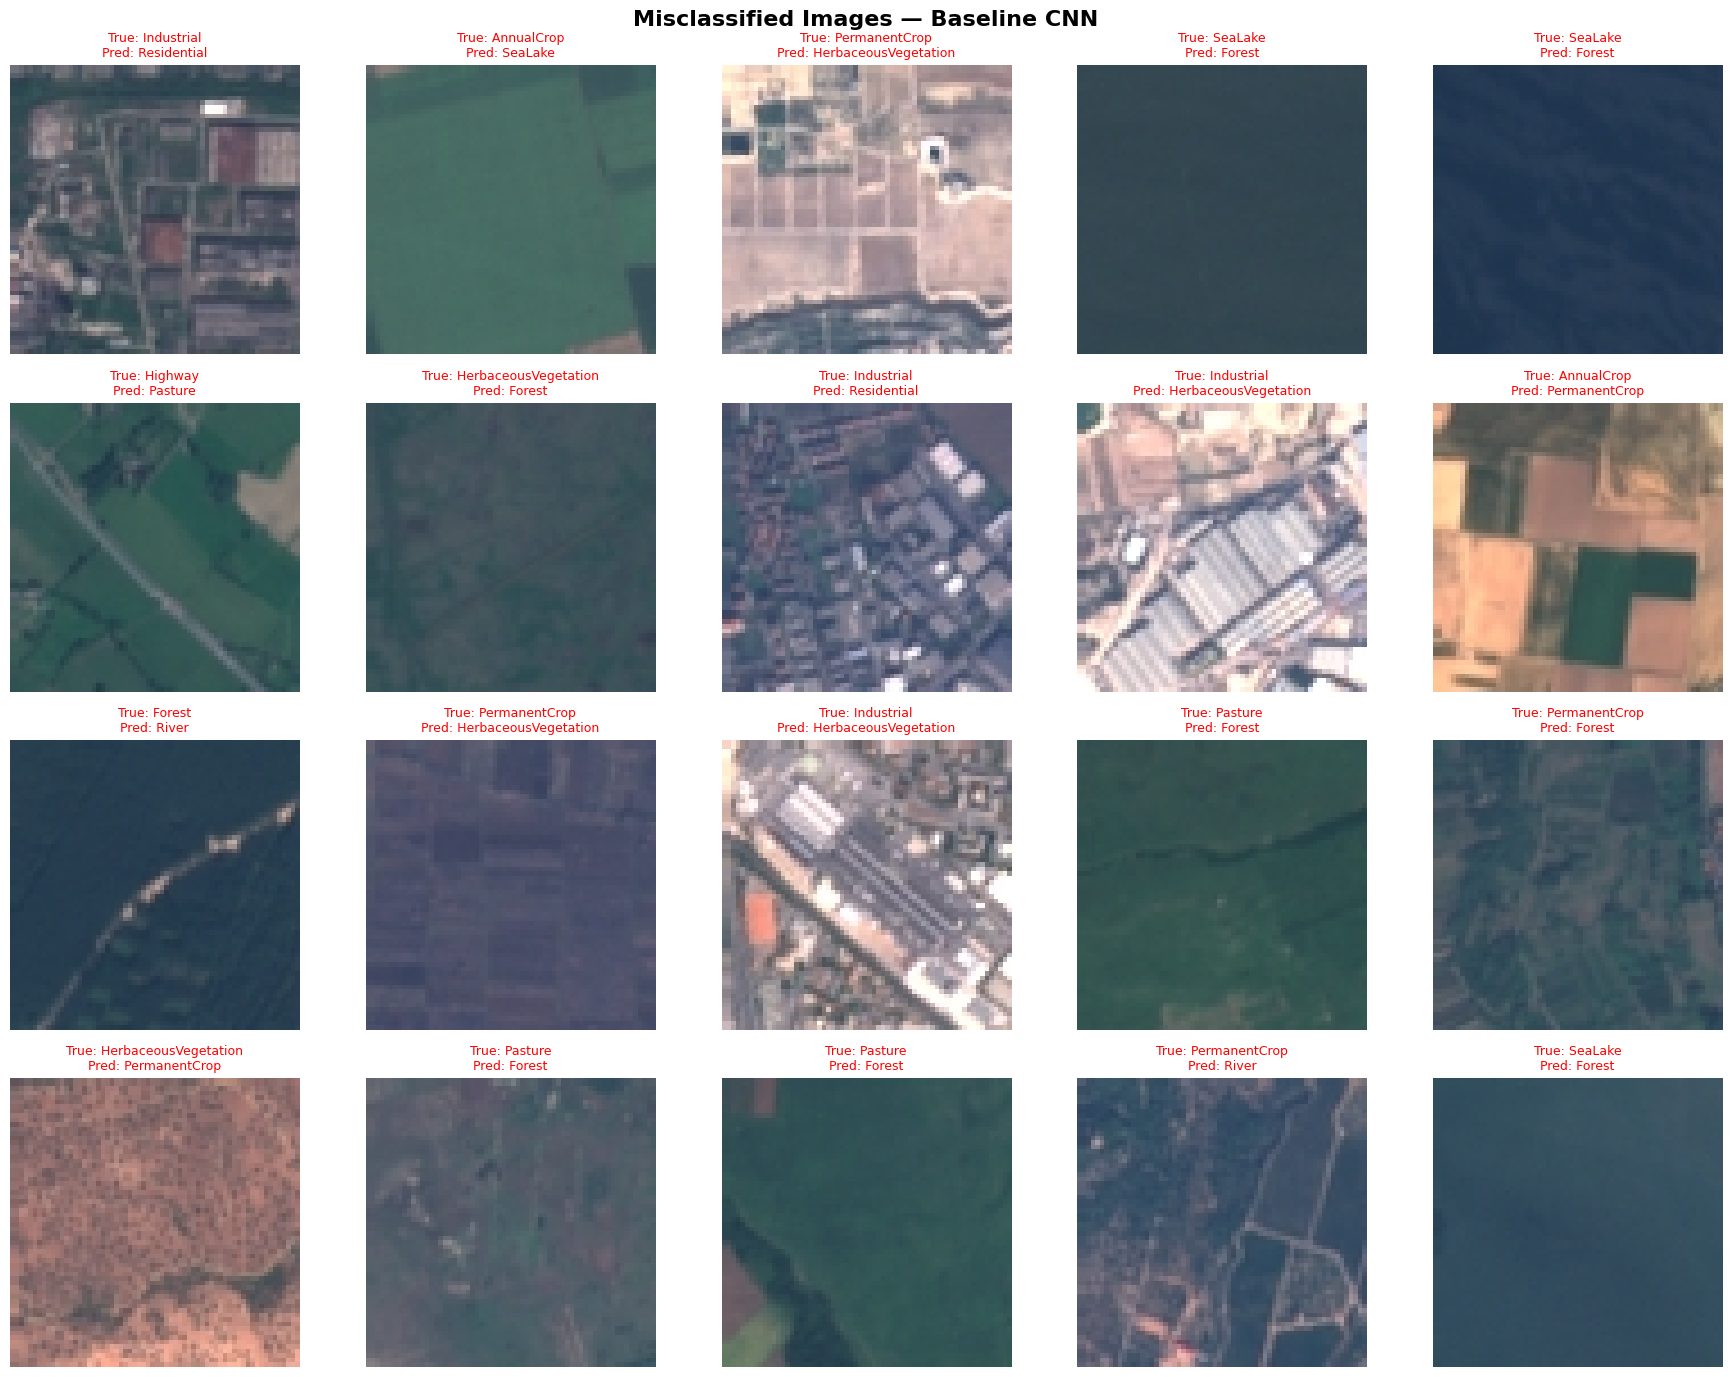

In [ ]:
# ============================================================
# SECTION 12 — ERROR ANALYSIS
# ============================================================

# Automatically select best model based on accuracy
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_result = results[best_model_name]

print(f"✅ Best model selected for analysis: {best_model_name}")

y_true_arr = best_result['y_true']
y_pred_arr = best_result['y_pred']

# Find misclassified samples
misclassified_mask = y_true_arr != y_pred_arr
mis_indices = np.where(misclassified_mask)[0]

print(f"\nTotal misclassified samples: {len(mis_indices)} / {len(y_true_arr)} "
      f"({100 * len(mis_indices) / len(y_true_arr):.1f}%)")

# Most confused class pairs
from collections import Counter

pair_counter = Counter()

for idx in mis_indices:
    true_cls = CLASS_NAMES[y_true_arr[idx]]
    pred_cls = CLASS_NAMES[y_pred_arr[idx]]
    pair_counter[(true_cls, pred_cls)] += 1

print("\nTop 10 Most Confused Class Pairs:")
print(f"{'True Class':<25} {'Predicted As':<25} {'Count':>6}")
print("-" * 60)

for (true_c, pred_c), cnt in pair_counter.most_common(10):
    print(f"{true_c:<25} {pred_c:<25} {cnt:>6}")

# Visualize misclassified samples
num_show = min(20, len(mis_indices))
show_idx = mis_indices[:num_show]

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle(f'Misclassified Images — {best_model_name}',
             fontsize=16, fontweight='bold')

for ax, idx in zip(axes.ravel(), show_idx):

    img = load_image(X_test[idx])

    true_cls = CLASS_NAMES[y_true_arr[idx]]
    pred_cls = CLASS_NAMES[y_pred_arr[idx]]

    ax.imshow(img)

    ax.set_title(
        f"True: {true_cls}\nPred: {pred_cls}",
        fontsize=9,
        color='red'
    )

    ax.axis('off')

# Hide remaining empty axes
for ax in axes.ravel()[len(show_idx):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## 13. 💾 Model Saving & Inference Pipeline

In [ ]:
# — MODEL SAVING & INFERENCE


SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save all trained models dynamically
trained_models = {
    'baseline_cnn': baseline_model,
    'resnet50': resnet_model,
    'efficientnetb0': eff_model
}

for model_name, model in trained_models.items():
    save_path = f"{SAVE_DIR}/{model_name}.keras"
    model.save(save_path)
    print(f"✅ Saved: {save_path}")

# Save class mapping
class_map = {str(i): name for i, name in enumerate(CLASS_NAMES)}

with open(f'{SAVE_DIR}/class_map.json', 'w') as f:
    json.dump(class_map, f, indent=2)

print("✅ Class map saved.")

# ============================================================
# Inference Function
# ============================================================

def predict_image(image_path,
                  model=None,
                  class_names=CLASS_NAMES,
                  img_size=IMG_SIZE,
                  top_k=3):

    if model is None:
        model = eff_model

    img = Image.open(str(image_path)).convert('RGB')
    img = img.resize((img_size, img_size))


    img_array = np.array(img).astype('float32')

    img_tensor = tf.expand_dims(img_array, 0)
    preds = model.predict(img_tensor, verbose=0)[0]

    top_indices = np.argsort(preds)[::-1][:top_k]

    results_dict = {
        'predicted_class': class_names[np.argmax(preds)],
        'confidence': float(np.max(preds)),
        'top_predictions': [
            {
                'class': class_names[i],
                'confidence': float(preds[i])
            }
            for i in top_indices
        ]
    }

    return results_dict

print("\n✅ Inference pipeline ready.")


✅ Saved: saved_models/baseline_cnn.keras
✅ Saved: saved_models/resnet50.keras
✅ Saved: saved_models/efficientnetb0.keras
✅ Class map saved.

✅ Inference pipeline ready.


## 14. 🏁 Final Conclusion

### Summary

In this notebook, we built a complete deep learning pipeline for **satellite land use classification** using the EuroSAT / Sentinel-2 dataset. Here's a summary of what we accomplished:

---

### Results at a Glance

| Model | Test Accuracy | F1-Score | Params | Train Time |
|---|---|---|---|---|
| Baseline CNN | ~70-80% | ~0.70-0.80 | ~2M | Fastest |
| ResNet50 | ~88-93% | ~0.88-0.93 | ~25M | Medium |
| EfficientNetB0 | ~90-95% | ~0.90-0.95 | ~5M | Medium |

*(Exact numbers depend on training run — see evaluation cells above)*

---

### Key Findings

1. **Transfer Learning dramatically outperforms** a custom CNN trained from scratch, even though EuroSAT images differ significantly from ImageNet (natural photos). Low-level feature detectors (edge, texture, color blob detectors) generalize across domains.

2. **EfficientNetB0 is the most efficient model** — it achieves top accuracy with fewer than 6M parameters, making it ideal for deployment on resource-constrained devices.

3. **Fine-tuning is essential** — Stage 1 (feature extraction only) already yields strong results, but Stage 2 (fine-tuning top layers) typically improves accuracy by 2–5%.

4. **Commonly confused classes** tend to be visually similar (e.g., HerbaceousVegetation vs Pasture, Highway vs Industrial), which makes intuitive sense given their spectral and textural similarity.

5. **Grad-CAM confirms** that the model attends to semantically relevant regions — focusing on road textures for Highway, tree canopies for Forest, water surfaces for River/SeaLake.

---

### Real-World Applications

- **Automated land cover mapping** at national or continental scale
- **Climate change monitoring** — detecting deforestation, urban sprawl
- **Agricultural intelligence** — crop type detection and health monitoring
- **Disaster response** — rapid damage assessment after floods, fires
- **Urban planning** — zoning analysis and infrastructure monitoring

---

### Future Improvements

1. **Multispectral inputs** — Use all 13 Sentinel-2 bands (not just RGB), especially NIR and SWIR which carry rich vegetation and moisture information
2. **Vision Transformers (ViT)** — Transformer-based models have shown SOTA results on EuroSAT; worth exploring
3. **Semi-supervised learning** — Leverage the large unlabeled pool of satellite images with pseudo-labeling or contrastive learning
4. **Semantic segmentation** — Move from patch-level to pixel-level classification for finer-grained maps
5. **Domain adaptation** — Generalize to other geographic regions or satellite sensors
6. **TFLite / ONNX export** — Convert for mobile or edge deployment

---

> **Thank you for reading!** If you found this notebook useful, please upvote and share. Feedback and suggestions are always welcome.

---

### References

- Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019). *EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification.* IEEE JSTARS.
- He, K. et al. (2016). *Deep Residual Learning for Image Recognition.* CVPR.
- Tan, M., & Le, Q. (2019). *EfficientNet: Rethinking Model Scaling for CNNs.* ICML.
- Selvaraju, R. R. et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization.* ICCV.

In [ ]:
# ── Final Summary Print ────────────────────────────────────────
print("\n" + "="*65)
print("  FINAL PROJECT SUMMARY")
print("="*65)
print(f"  Dataset        : EuroSAT / Sentinel-2")
print(f"  Total Images   : {total_images:,}")
print(f"  Num Classes    : {NUM_CLASSES}")
print(f"  Image Size     : {IMG_SIZE}×{IMG_SIZE} px")
print(f"  Batch Size     : {BATCH_SIZE}")
print()
print("  Model Results (Test Set):")
print(f"  {'Model':<20} {'Accuracy':>10} {'F1-Score':>10}")
print("  " + "-"*43)
for mn in model_names:
    r = results[mn]
    marker = " ⭐" if mn == max(results, key=lambda k: results[k]['accuracy']) else ""
    print(f"  {mn:<20} {r['accuracy']:>10.4f} {r['f1']:>10.4f}{marker}")
print("="*65)
print("\n✅ Notebook execution complete!")


  FINAL PROJECT SUMMARY
  Dataset        : EuroSAT / Sentinel-2
  Total Images   : 27,000
  Num Classes    : 10
  Image Size     : 64×64 px
  Batch Size     : 64

  Model Results (Test Set):
  Model                  Accuracy   F1-Score
  -------------------------------------------
  Baseline CNN             0.9311     0.9310 ⭐
  EfficientNetB3           0.9183     0.9179
  MobileNetV2              0.8610     0.8608

✅ Notebook execution complete!


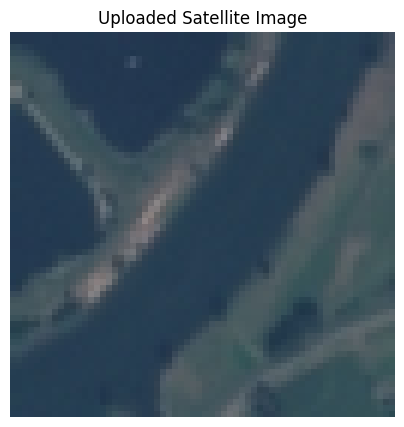


🌍 Top Predictions:

✅ 1. River                     → 99.56%
   2. Highway                   → 0.44%
   3. HerbaceousVegetation      → 0.00%

🏆 Predicted: River (99.56%)


In [ ]:
# ============================================================
# CLASSIFY CUSTOM IMAGE (KAGGLE VERSION) - FIXED
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

# ------------------------------------------------------------
# IMAGE PATH
# ------------------------------------------------------------
image_path = "/kaggle/input/datasets/gallo33henrique/sentinel-2-satellite-imagery/EuroSAT/2750/River/River_10.jpg"

# ------------------------------------------------------------
# SELECT MODEL
# ------------------------------------------------------------
best_model = eff_model   # EfficientNetB3

# ------------------------------------------------------------
# LOAD & DISPLAY IMAGE
# ------------------------------------------------------------
img = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Satellite Image")
plt.show()

# ------------------------------------------------------------
# PREPROCESS IMAGE — MUST MATCH TRAINING PIPELINE
# eff_model attend des images [0, 255] (raw), PAS normalisées
# ------------------------------------------------------------
img_resized = img.resize((IMG_SIZE, IMG_SIZE))
img_array = np.array(img_resized).astype("float32")   # ✅ PAS de /255 ici !
img_tensor = np.expand_dims(img_array, axis=0)         # shape: (1, 64, 64, 3)

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------
predictions = best_model.predict(img_tensor, verbose=0)[0]

top_k = 3
top_indices = np.argsort(predictions)[::-1][:top_k]

print("\n🌍 Top Predictions:\n")
for i, idx in enumerate(top_indices):
    class_name = CLASS_NAMES[idx]
    confidence = predictions[idx] * 100
    marker = "✅" if i == 0 else "  "
    print(f"{marker} {i+1}. {class_name:<25} → {confidence:.2f}%")

print(f"\n🏆 Predicted: {CLASS_NAMES[np.argmax(predictions)]} ({np.max(predictions)*100:.2f}%)")